# Métodos de Analítica II - Proyecto Caso de Negocio

### Preparación

Se importarán las librerías necesarias para el manejo de datos, como pandas o numpy; para realizar las gráficas, como matplotlib y seaborn; y para los modelos. Se utilizará scikit-learn, xgboost y pytorch.

In [59]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import xgboost as xgb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from catboost import CatBoostRegressor
import shap
import time
import warnings

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, ParameterSampler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, ElasticNetCV
from scipy.stats import uniform, loguniform
from catboost import CatBoostRegressor, Pool, cv

warnings.filterwarnings("ignore")

Se lee el archivo csv con los datos a utilizar.

In [2]:
# Leer el archivo CSV
df = pd.read_csv('peso_bebes.csv')

Al analizar el enunciado del proyecto, se identifican varias variables que resultan irrelevantes o inadecuadas para el modelo por distintas razones. En primer lugar, algunas corresponden a mediciones realizadas durante o después del nacimiento del bebé (como el día del parto o el puntaje Apgar), lo que introduce data leakage al incorporar información que no estaría disponible en el momento de la predicción. Asimismo, existen variables que no aportan valor explicativo, como el año, dado que todos los registros pertenecen al mismo periodo.

En la siguiente celda se presentan las columnas que fueron eliminadas junto con la justificación correspondiente. Posteriormente, y con base en los resultados del EDA, se evaluará la eliminación o transformación adicional de otras variables.


In [3]:
# Eliminar las columnas que no se necesitan
columns_to_drop = [
    'weight_pounds',      # Variable objetivo (target)
    'apgar_1min',         # Se mide después del nacimiento (leakage)
    'apgar_5min',         # Se mide después del nacimiento (leakage)
    'source_year',        # Constante (todos son 2022) y redundante
    'year',               # Constante y redundante
    'record_weight',      # Peso de muestreo estadístico, no predictivo
    'ever_born',          # Incluye nacimiento actual (leakage sutil)
    'lmp',                # Redundante con gestation_weeks, formato sucio
    'child_race',         # Redundante con mother_race y father_race
    'state',              # No se conoce antes del parto, redundante con mother_residence_state
    'day',                # Día exacto de nacimiento no se conoce antes
    'wday',               # Día de la semana no se conoce antes
]

X = df.drop(columns=columns_to_drop)
y = df['weight_pounds']

In [4]:
# Ver cómo está construido el DataFrame después de eliminar las columnas
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4255156 entries, 0 to 4255155
Data columns (total 19 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   month                   int64  
 1   is_male                 bool   
 2   plurality               int64  
 3   mother_residence_state  float64
 4   mother_race             float64
 5   mother_age              int64  
 6   gestation_weeks         float64
 7   mother_married          bool   
 8   mother_birth_state      float64
 9   cigarette_use           object 
 10  cigarettes_per_day      float64
 11  alcohol_use             object 
 12  drinks_per_week         float64
 13  weight_gain_pounds      float64
 14  born_alive_alive        float64
 15  born_alive_dead         float64
 16  born_dead               float64
 17  father_race             float64
 18  father_age              int64  
dtypes: bool(2), float64(11), int64(4), object(2)
memory usage: 560.0+ MB


In [5]:
X.head()

,month,is_male,plurality,mother_residence_state,mother_race,mother_age,gestation_weeks,mother_married,mother_birth_state,cigarette_use,cigarettes_per_day,alcohol_use,drinks_per_week,weight_gain_pounds,born_alive_alive,born_alive_dead,born_dead,father_race,father_age
0,4,False,1,NaN,NaN,34,38.0,True,NaN,NaN,NaN,NaN,NaN,30.0,NaN,NaN,NaN,NaN,49
1,3,False,1,NaN,NaN,38,40.0,True,NaN,NaN,NaN,NaN,NaN,99.0,NaN,NaN,NaN,NaN,45
2,12,True,1,NaN,NaN,30,36.0,False,NaN,NaN,NaN,NaN,NaN,54.0,NaN,NaN,NaN,NaN,38
3,10,True,1,NaN,NaN,31,38.0,False,NaN,NaN,NaN,NaN,NaN,30.0,NaN,NaN,NaN,NaN,39
4,11,False,1,NaN,NaN,39,39.0,True,NaN,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,40


In [6]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 4255156 entries, 0 to 4255155
Series name: weight_pounds
Non-Null Count    Dtype  
--------------    -----  
4250791 non-null  float64
dtypes: float64(1)
memory usage: 32.5 MB


Se convierten las variables a los tipos de datos adecuados para facilitar su manejo y optimizar el análisis, incluyendo aquellas que deben representarse como booleanas, enteras o decimales.

In [7]:
# Convertir las variables a los tipos correctos

# --- Variables booleanas ---
X['is_male'] = X['is_male'].astype('bool')
X['mother_married'] = X['mother_married'].astype('bool')

# cigarette_use y alcohol_use: convertir strings a boolean nullable (preserva NaN)
X['cigarette_use'] = X['cigarette_use'].map({
    'True': True, 'true': True, 
    'False': False, 'false': False
}).astype('boolean')
X['alcohol_use'] = X['alcohol_use'].map({
    'True': True, 'true': True, 
    'False': False, 'false': False
}).astype('boolean')

# --- Variables categóricas ---
X['month'] = X['month'].astype('category')
X['mother_residence_state'] = X['mother_residence_state'].astype('category')
X['mother_race'] = X['mother_race'].astype('category')
X['mother_birth_state'] = X['mother_birth_state'].astype('category')
X['father_race'] = X['father_race'].astype('category')


# --- Variables numéricas ---
cols_numericas = [
    'mother_age', 'father_age', 'plurality', 'gestation_weeks', 
    'cigarettes_per_day', 'drinks_per_week', 'weight_gain_pounds', 
    'born_alive_alive', 'born_alive_dead', 'born_dead'
]

for col in cols_numericas:
    # Ignoramos los nulos temporalmente para hacer la comprobación matemática
    sin_nulos = X[col].dropna()
    
    # Verificamos si la columna tiene datos y si todos sus valores equivalen a enteros
    if not sin_nulos.empty and (sin_nulos % 1 == 0).all():
        # Es un entero (o un float que en realidad esconde enteros). 
        # Usamos 'Int32' (Int con mayúscula) para soportar posibles NaNs.
        X[col] = X[col].astype('Int32')
    else:
        # Tiene decimales reales o está completamente vacía.
        X[col] = X[col].astype('float32')

In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4255156 entries, 0 to 4255155
Data columns (total 19 columns):
 #   Column                  Dtype   
---  ------                  -----   
 0   month                   category
 1   is_male                 bool    
 2   plurality               Int32   
 3   mother_residence_state  category
 4   mother_race             category
 5   mother_age              Int32   
 6   gestation_weeks         Int32   
 7   mother_married          bool    
 8   mother_birth_state      category
 9   cigarette_use           boolean 
 10  cigarettes_per_day      Int32   
 11  alcohol_use             boolean 
 12  drinks_per_week         float32 
 13  weight_gain_pounds      Int32   
 14  born_alive_alive        float32 
 15  born_alive_dead         float32 
 16  born_dead               float32 
 17  father_race             category
 18  father_age              Int32   
dtypes: Int32(6), bool(2), boolean(2), category(5), float32(4)
memory usage: 231.3 MB


In [9]:
# Lista de columnas numéricas y categóricas para análisis
cols_numericas = X.select_dtypes(include=[np.number]).columns.tolist()
cols_categoricas = X.select_dtypes(include=['category', 'object', 'bool']).columns.tolist()

Se establece una constante para la semilla única que se usará a lo largo del Notebook, para garantizar replicabilidad

In [10]:
SEED = 42

Antes de aplicar cualquier otro tratamiento a los datos y de realizar el EDA, se dividirá la base de datos en conjuntos de entrenamiento y test, utilizando una proporción 80/20. El conjunto de test se mantendrá intacto durante todo el proceso para evitar data leakage y se utilizará únicamente en la evaluación final del desempeño de cada modelo.

In [11]:
## Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

## Análisis Exploratorio de Datos

El análisis se dividirá en dos fases. En primer lugar, se realizará un análisis univariado para evaluar la consistencia de los datos en cada columna, así como su tendencia central, dispersión, distribución y la presencia de valores faltantes. Posteriormente, se llevará a cabo un análisis multivariado con el fin de examinar la relación entre las variables explicativas y la variable objetivo, así como las interacciones entre ellas.

### Análisis Univariado

In [12]:
# Función para analizar variables numéricas
def analizar_numerica(df, columna):
    data = df[columna].dropna()
    
    # Cálculos estadísticos
    stats_dict = {
        'Media': data.mean(),
        'Mediana': data.median(),
        'Varianza': data.var(),
        'Desv. Est.': data.std(),
        'Asimetría': stats.skew(data),
        'Curtosis': stats.kurtosis(data)
    }
    
    missing_count = df[columna].isnull().sum()
    missing_pct = missing_count / len(df) * 100
    
    print(f"### {columna}")
    print(pd.DataFrame([stats_dict]).to_markdown(index=False))
    print(f"Valores faltantes: {missing_count} ({missing_pct:.2f}%)")
    
    # Gráficos
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    n_bins = min(30, data.nunique())
    sns.histplot(data, bins=n_bins, ax=ax[0], color='skyblue')
    # -------------------------------------
    
    ax[0].set_title(f'Histograma de {columna}')
    ax[0].set_xlabel(columna)
    ax[0].set_ylabel('Frecuencia')
    
    sns.boxplot(x=data, ax=ax[1], color='lightgreen')
    ax[1].set_title(f'Diagrama de caja de {columna}')
    ax[1].set_xlabel(columna)
    
    plt.tight_layout()
    plt.show()

In [13]:
# Función para analizar variables categóricas
def analizar_categorica(df, columna):
    mode_val = df[columna].mode()
    moda = mode_val[0] if not mode_val.empty else 'Sin moda'
    unicos = df[columna].nunique()
    faltantes = df[columna].isnull().sum()
    
    print(f"### {columna}")
    print(f"Moda: {moda}")
    print(f"Valores únicos: {unicos}")
    print(f"Valores faltantes: {faltantes}")
    
    # Gráfico
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=columna, order=df[columna].value_counts().index, hue=columna, palette='viridis', legend=False)
    plt.title(f'Gráfico de conteo de {columna}')
    plt.xlabel(columna)
    plt.ylabel('Conteo')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

## Variables Numéricas en X_train
### plurality
|   Media |   Mediana |   Varianza |   Desv. Est. |   Asimetría |   Curtosis |
|--------:|----------:|-----------:|-------------:|------------:|-----------:|
| 1.03575 |         1 |  0.0378379 |      0.19452 |     5.77022 |    37.1993 |
Valores faltantes: 0 (0.00%)


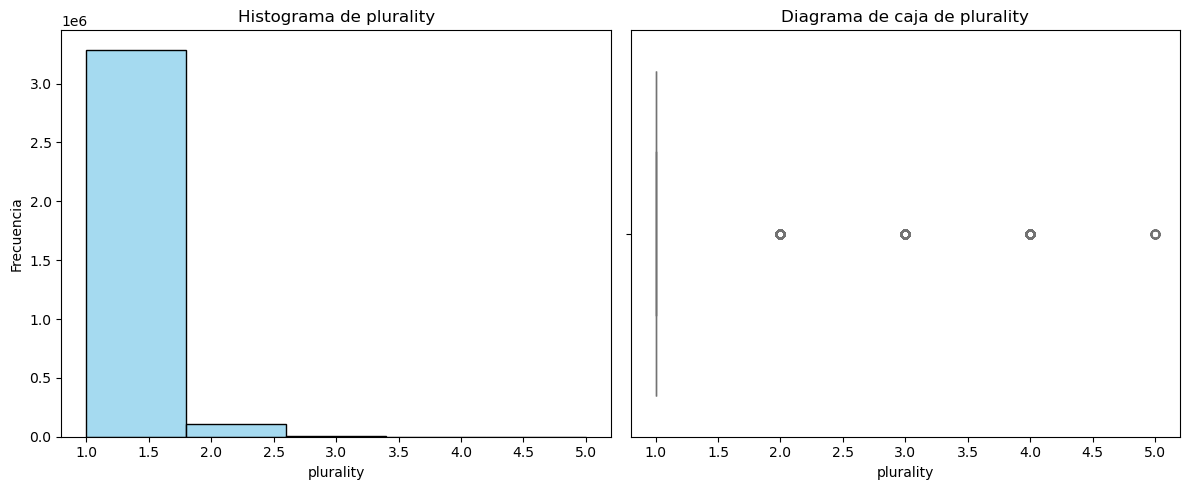

### mother_age
|   Media |   Mediana |   Varianza |   Desv. Est. |   Asimetría |   Curtosis |
|--------:|----------:|-----------:|-------------:|------------:|-----------:|
| 27.4108 |        27 |    37.9125 |      6.15731 |    0.248497 |  -0.567413 |
Valores faltantes: 0 (0.00%)


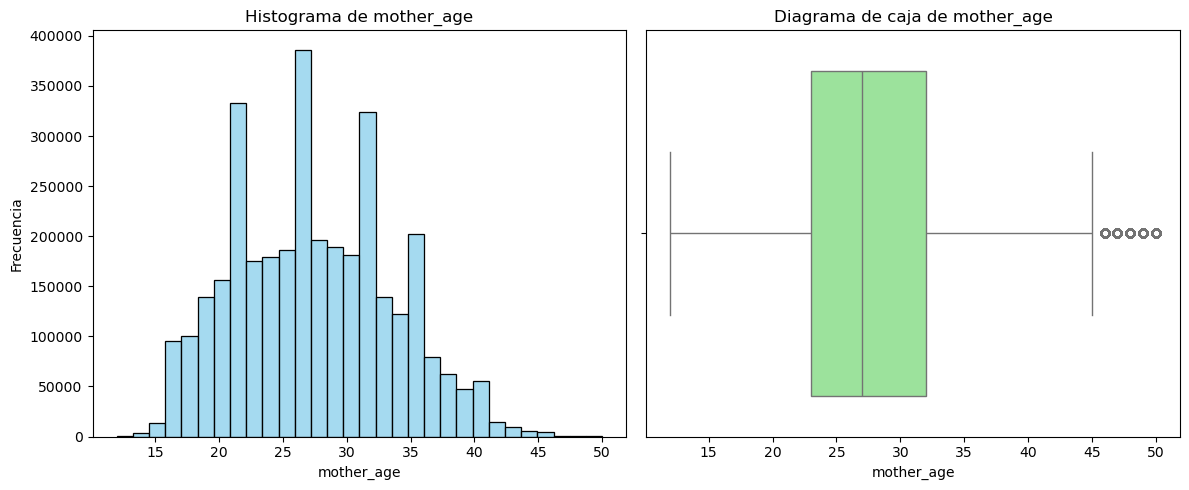

### gestation_weeks
|   Media |   Mediana |   Varianza |   Desv. Est. |   Asimetría |   Curtosis |
|--------:|----------:|-----------:|-------------:|------------:|-----------:|
|   38.57 |        39 |    6.49322 |      2.54818 |    -1.93479 |    9.58762 |
Valores faltantes: 4608 (0.14%)


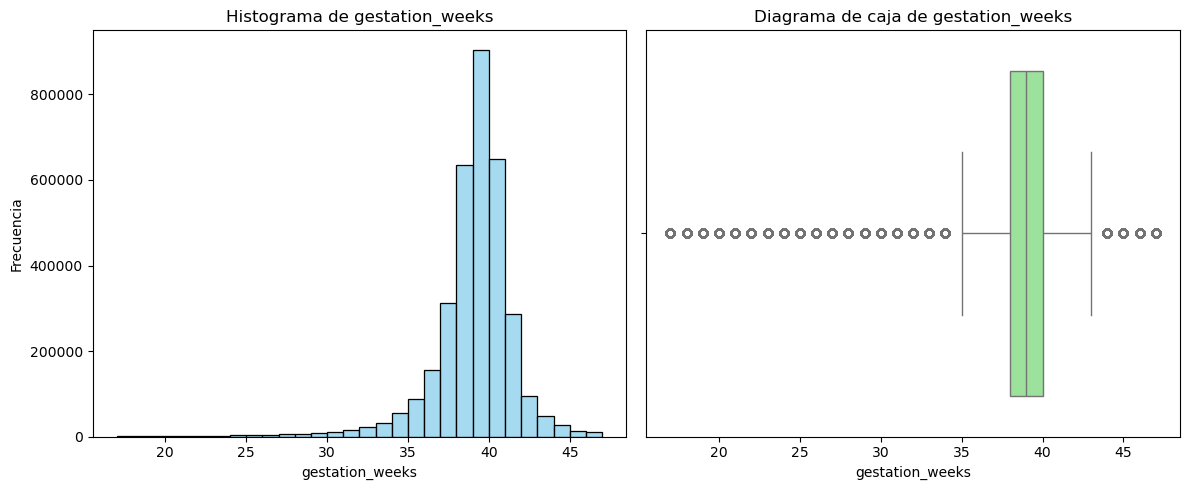

### cigarettes_per_day
|   Media |   Mediana |   Varianza |   Desv. Est. |   Asimetría |   Curtosis |
|--------:|----------:|-----------:|-------------:|------------:|-----------:|
| 11.0836 |        10 |     240.78 |      15.5171 |     4.71502 |    23.7646 |
Valores faltantes: 3290727 (96.67%)


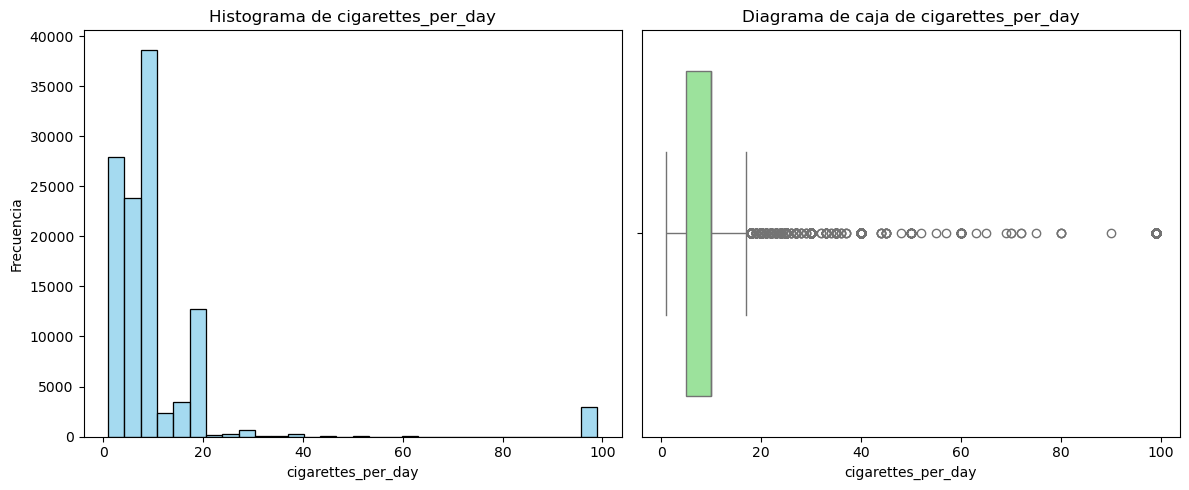

### drinks_per_week
|   Media |   Mediana |   Varianza |   Desv. Est. |   Asimetría |   Curtosis |
|--------:|----------:|-----------:|-------------:|------------:|-----------:|
|     nan |       nan |        nan |          nan |         nan |        nan |
Valores faltantes: 3404124 (100.00%)


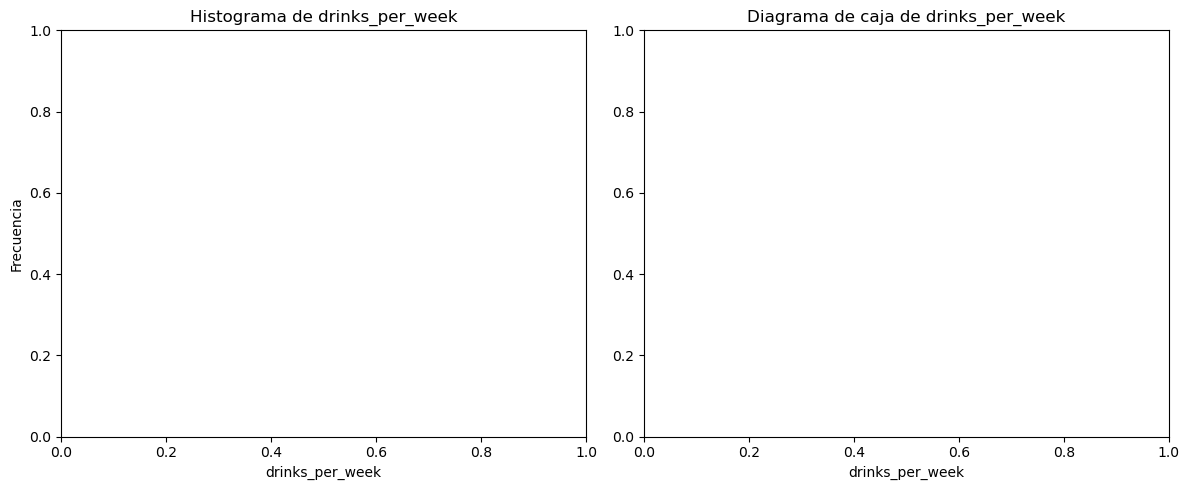

### weight_gain_pounds
|   Media |   Mediana |   Varianza |   Desv. Est. |   Asimetría |   Curtosis |
|--------:|----------:|-----------:|-------------:|------------:|-----------:|
| 35.6611 |        31 |    457.196 |      21.3821 |     1.59244 |    2.60766 |
Valores faltantes: 75867 (2.23%)


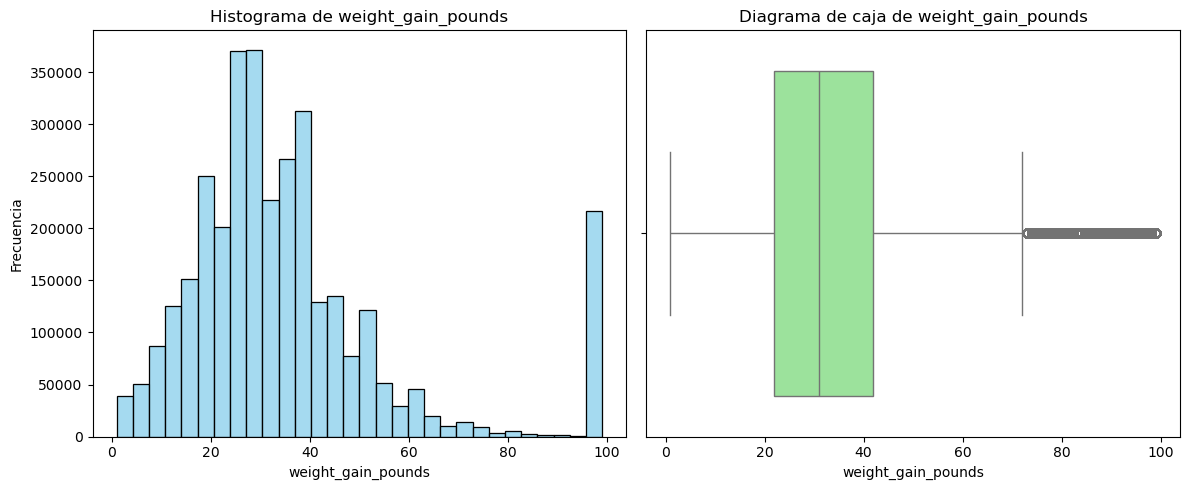

### born_alive_alive
|   Media |   Mediana |   Varianza |   Desv. Est. |   Asimetría |   Curtosis |
|--------:|----------:|-----------:|-------------:|------------:|-----------:|
|     nan |       nan |        nan |          nan |         nan |        nan |
Valores faltantes: 3404124 (100.00%)


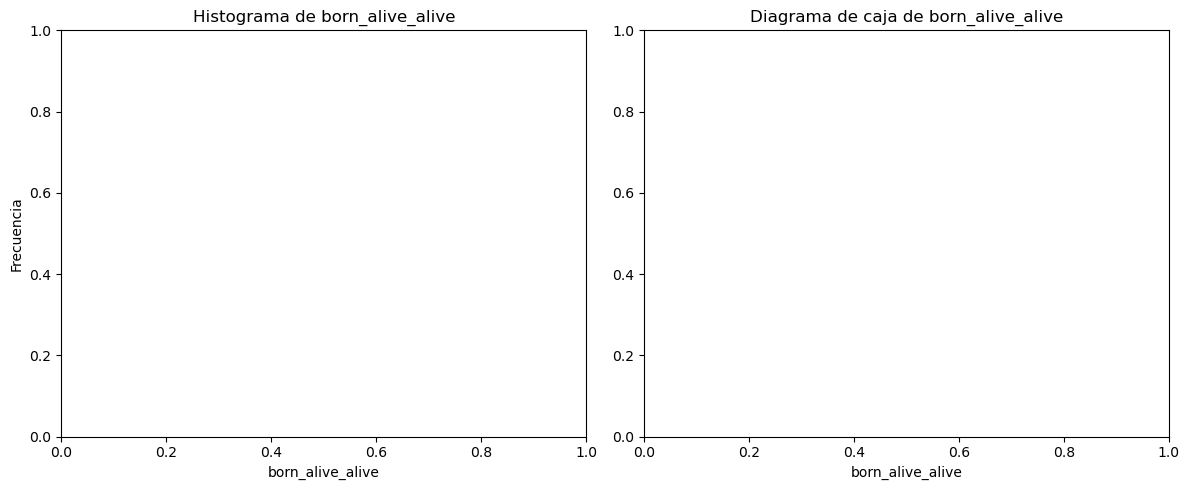

### born_alive_dead
|   Media |   Mediana |   Varianza |   Desv. Est. |   Asimetría |   Curtosis |
|--------:|----------:|-----------:|-------------:|------------:|-----------:|
|     nan |       nan |        nan |          nan |         nan |        nan |
Valores faltantes: 3404124 (100.00%)


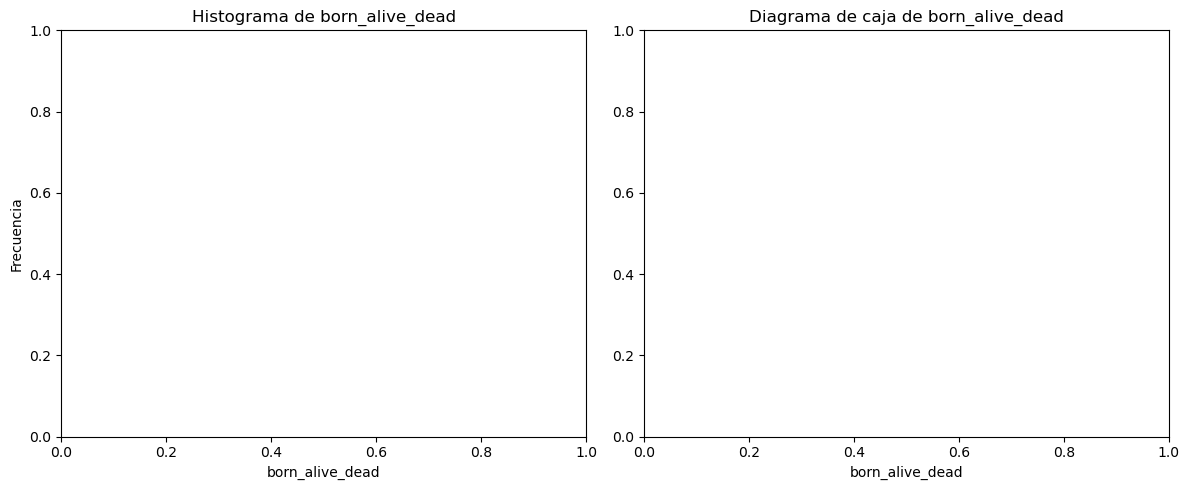

### born_dead
|   Media |   Mediana |   Varianza |   Desv. Est. |   Asimetría |   Curtosis |
|--------:|----------:|-----------:|-------------:|------------:|-----------:|
|     nan |       nan |        nan |          nan |         nan |        nan |
Valores faltantes: 3404124 (100.00%)


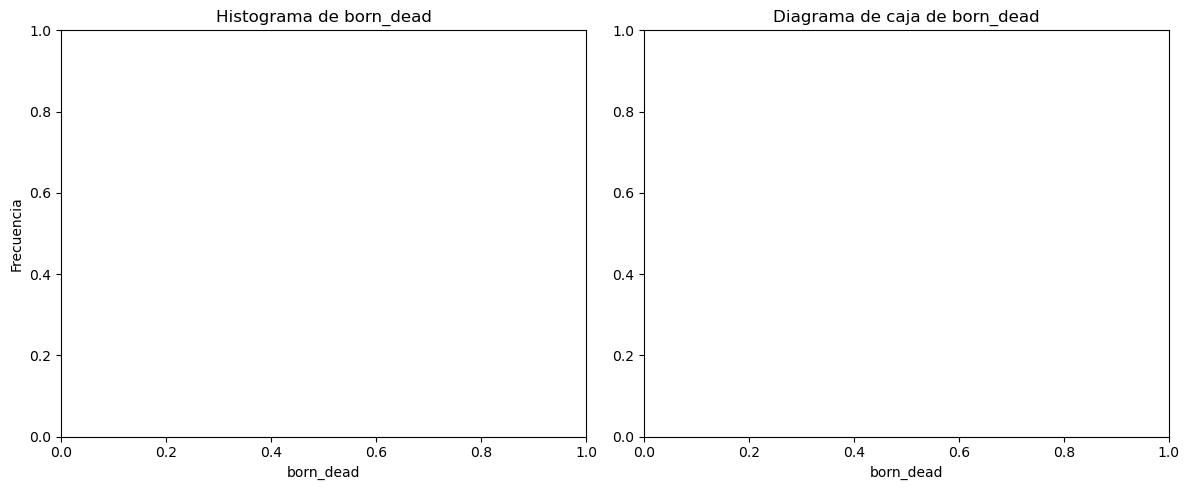

### father_age
|   Media |   Mediana |   Varianza |   Desv. Est. |   Asimetría |   Curtosis |
|--------:|----------:|-----------:|-------------:|------------:|-----------:|
| 40.0755 |        31 |    606.287 |      24.6229 |     1.79404 |    1.66946 |
Valores faltantes: 0 (0.00%)


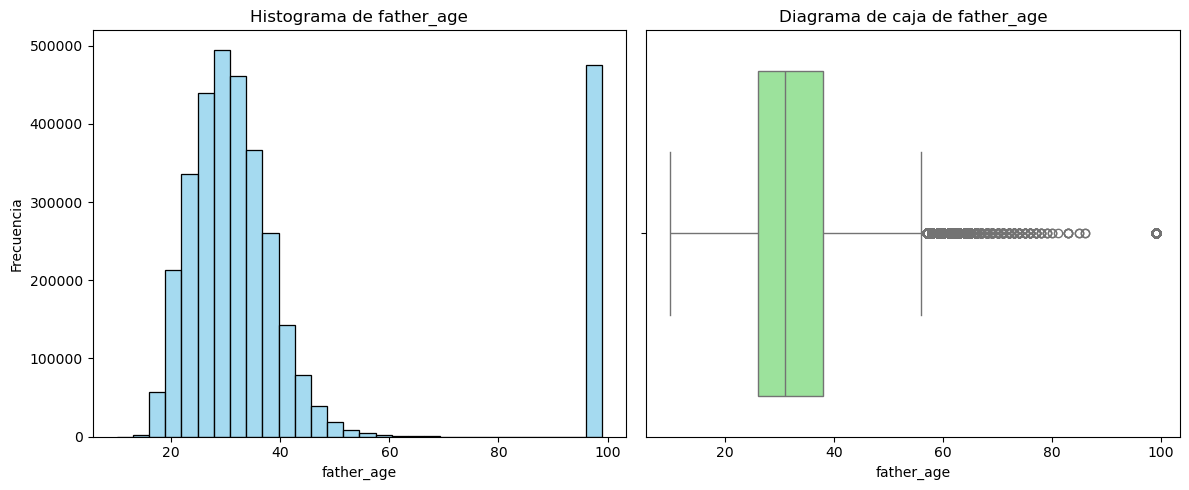

## Variables Categóricas en X_train
### month
Moda: 7
Valores únicos: 12
Valores faltantes: 0


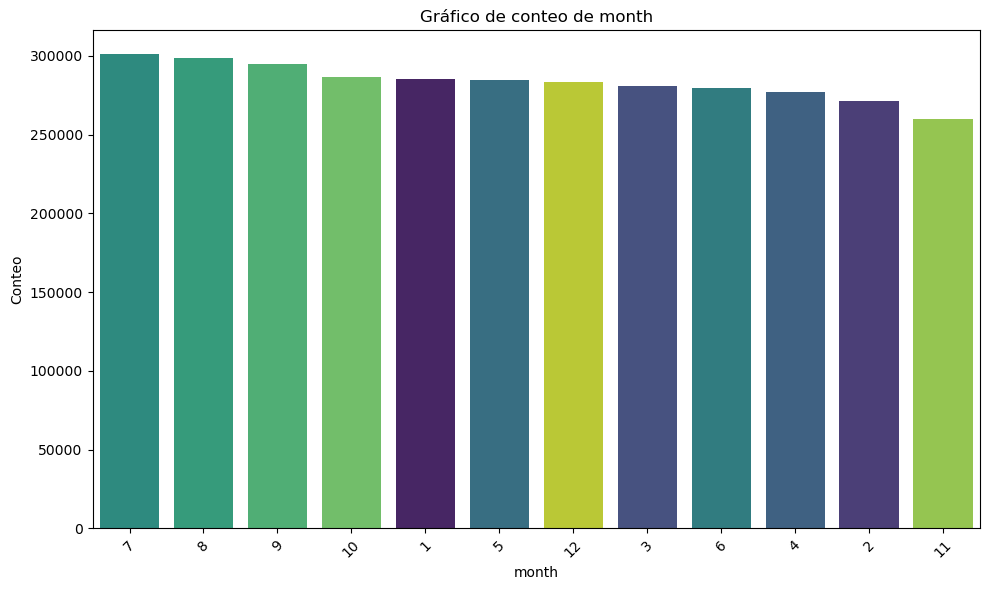

### is_male
Moda: True
Valores únicos: 2
Valores faltantes: 0


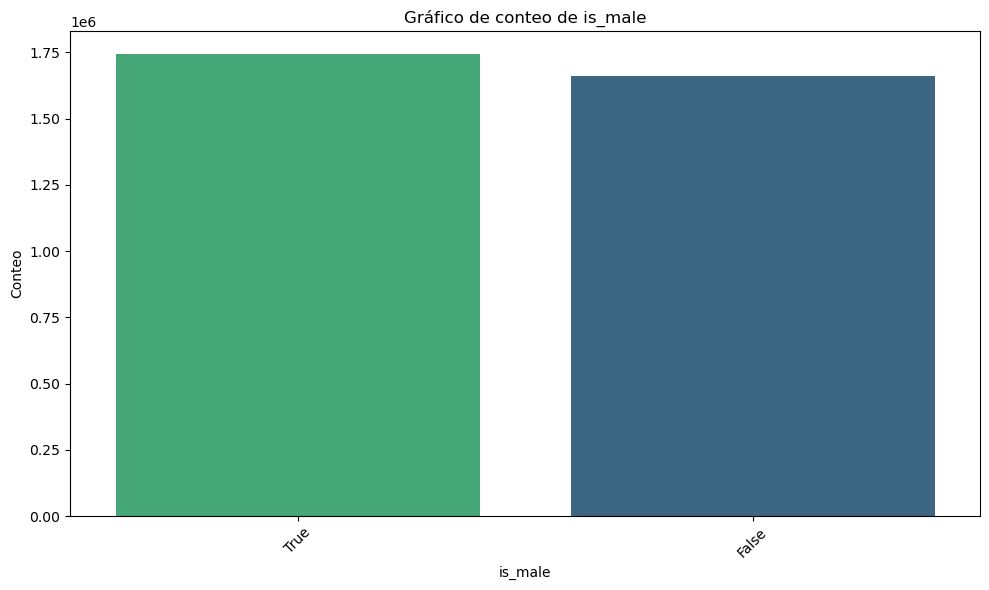

### mother_residence_state
Moda: Sin moda
Valores únicos: 0
Valores faltantes: 3404124


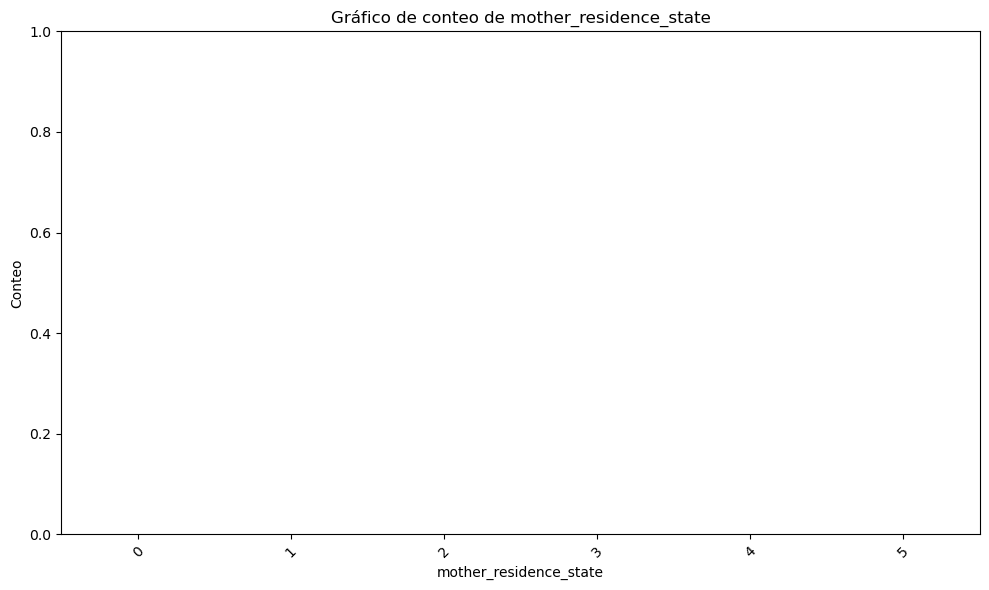

### mother_race
Moda: 1.0
Valores únicos: 14
Valores faltantes: 2330674


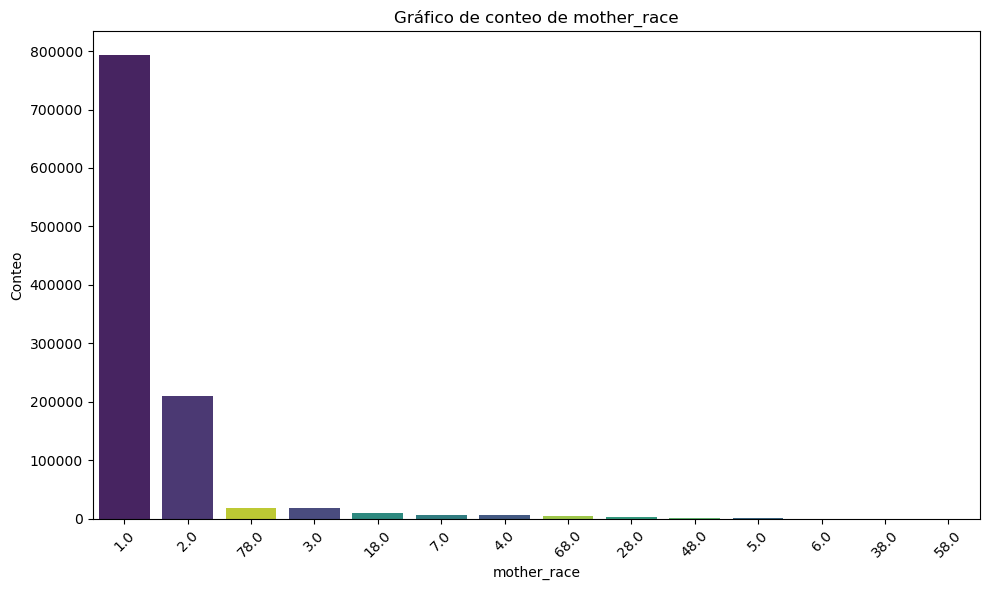

### mother_married
Moda: True
Valores únicos: 2
Valores faltantes: 0


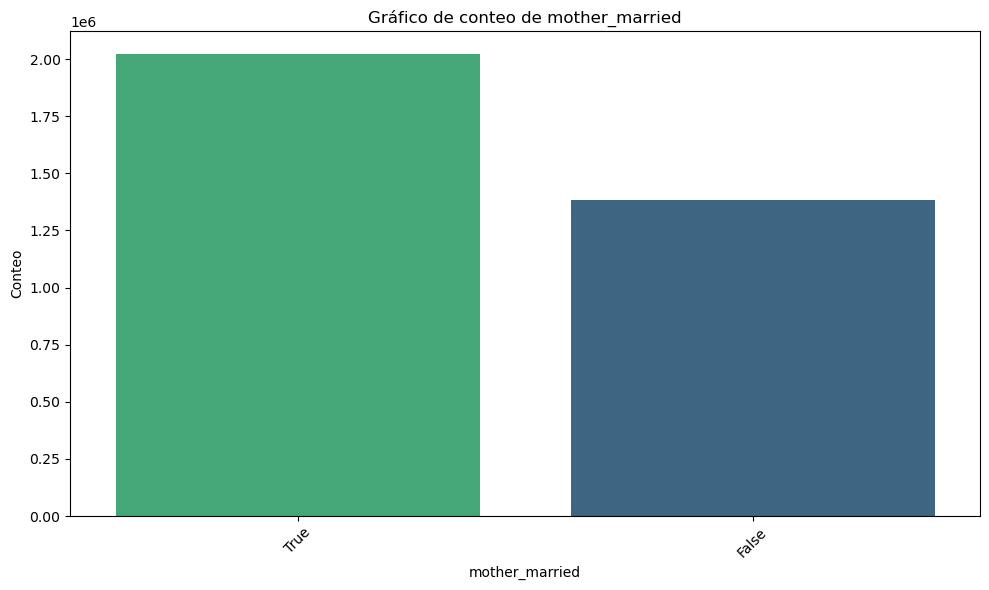

### mother_birth_state
Moda: Sin moda
Valores únicos: 0
Valores faltantes: 3404124


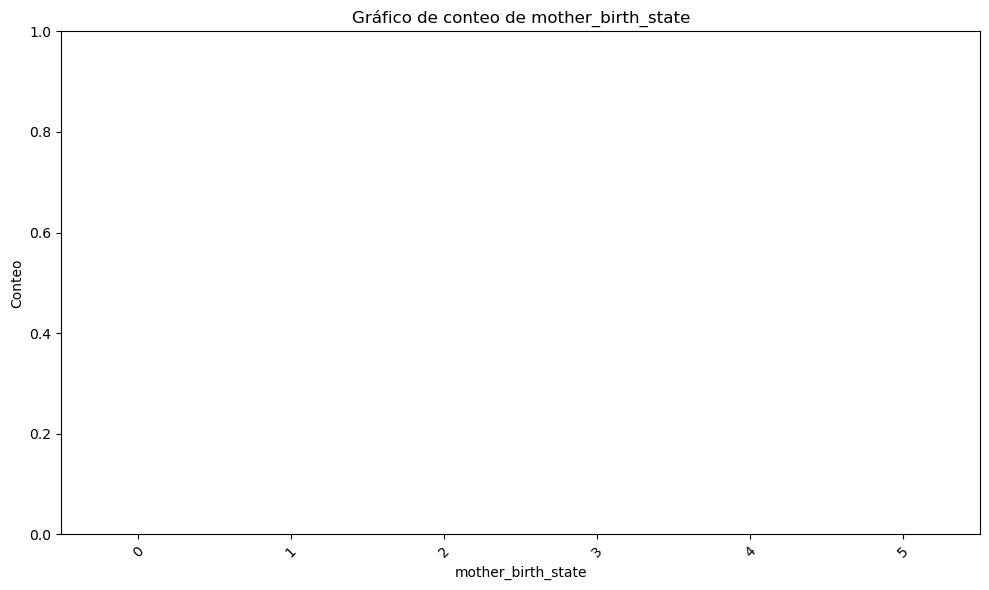

### cigarette_use
Moda: Sin moda
Valores únicos: 0
Valores faltantes: 3404124


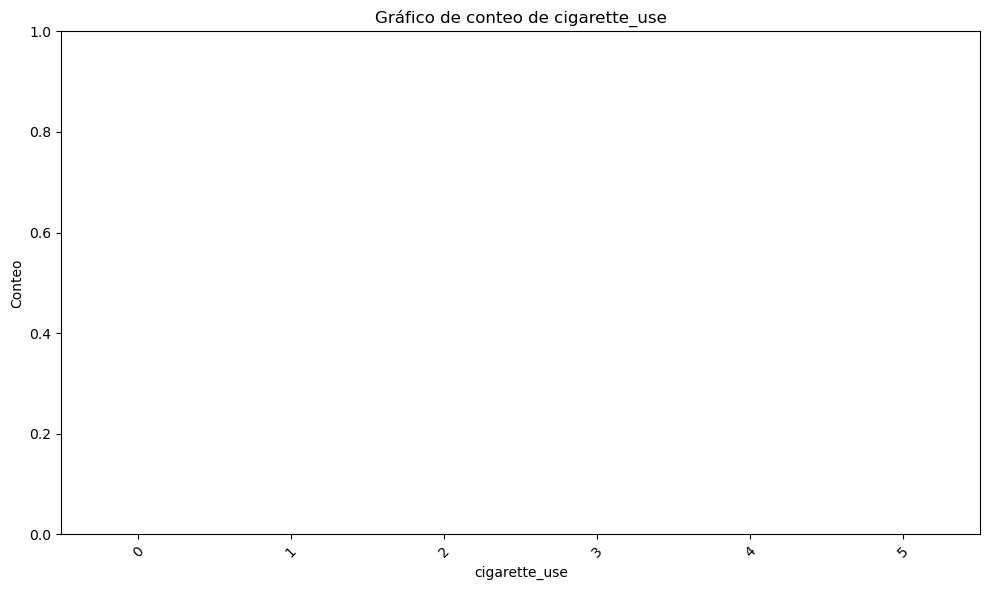

### alcohol_use
Moda: Sin moda
Valores únicos: 0
Valores faltantes: 3404124


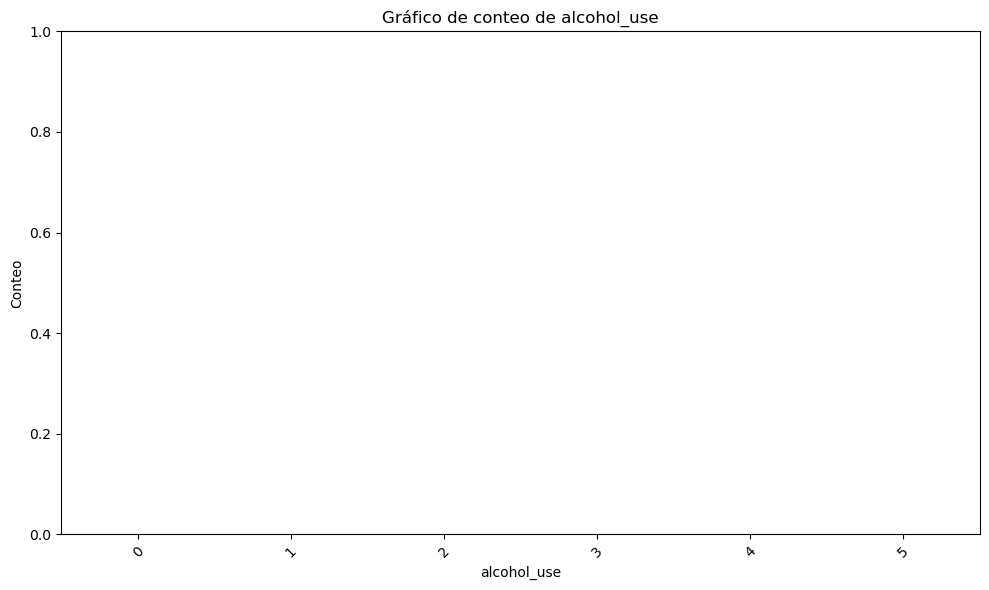

### father_race
Moda: 1.0
Valores únicos: 15
Valores faltantes: 2330674


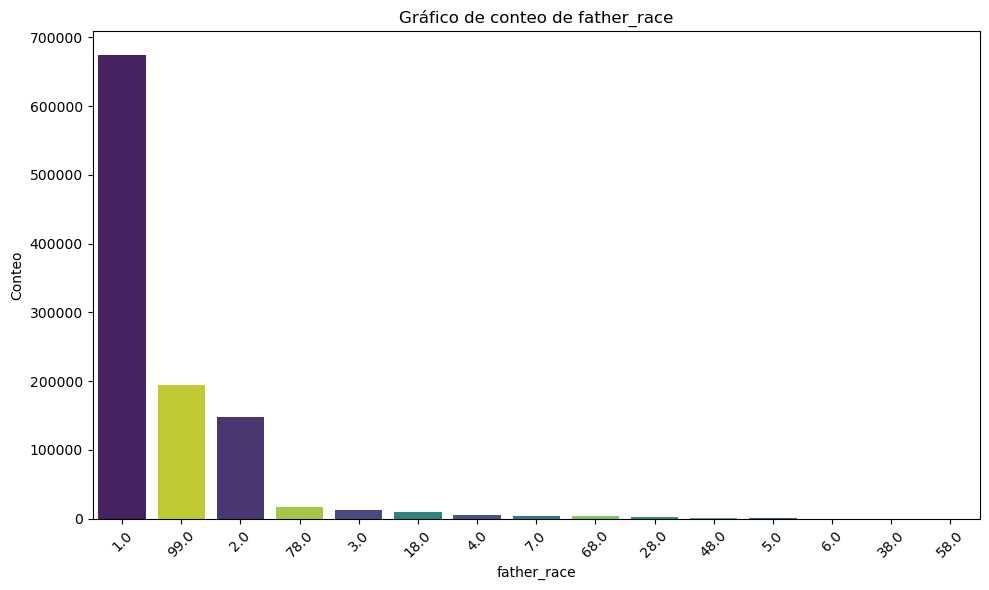

## Variable Objetivo y_train
### peso_libras
|   Media |   Mediana |   Varianza |   Desv. Est. |   Asimetría |   Curtosis |
|--------:|----------:|-----------:|-------------:|------------:|-----------:|
| 7.19221 |   7.27746 |    1.70319 |      1.30506 |   -0.904806 |    2.88906 |
Valores faltantes: 3474 (0.10%)


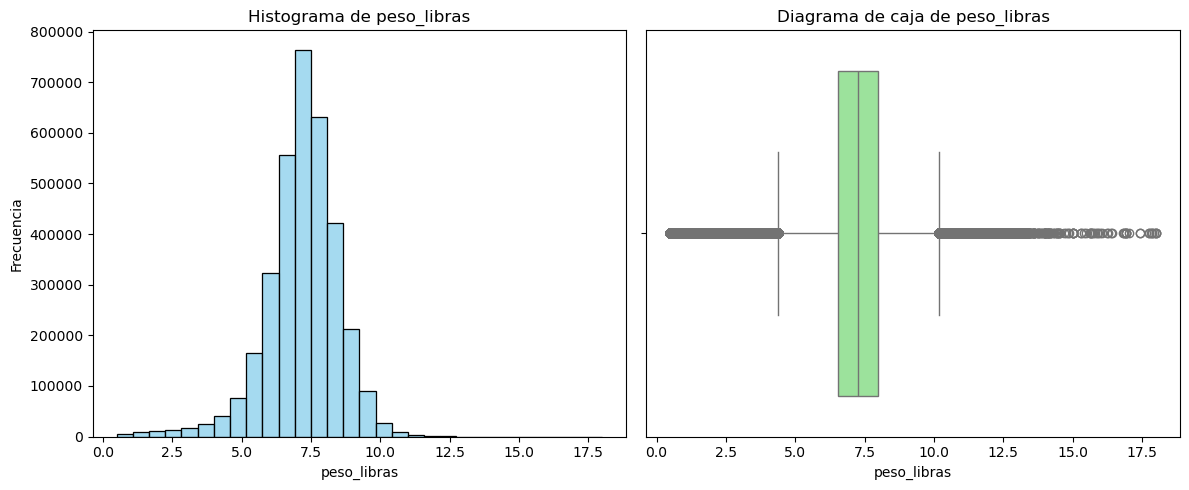

In [14]:
# --- EJECUCIÓN DEL ANÁLISIS ---

# Analizar variables numéricas en X_train
print("## Variables Numéricas en X_train")
for col in cols_numericas:
    analizar_numerica(X_train, col)

# Analizar variables categóricas en X_train
print("## Variables Categóricas en X_train")
for col in cols_categoricas:
    analizar_categorica(X_train, col)

# Analizar y_train 
print("## Variable Objetivo y_train")
analizar_numerica(pd.DataFrame({'peso_libras': y_train}), 'peso_libras')

### Tabla Resumen de Estadísticos

In [15]:
# --- Tabla resumen: Variables Numéricas ---
resumen_num = []

for col in cols_numericas:
    data = X_train[col].dropna()
    resumen_num.append({
        'Variable': col,
        'Count': len(data),
        'Nulos': X_train[col].isnull().sum(),
        '% Nulos': round(X_train[col].isnull().sum() / len(X_train) * 100, 2),
        'Media': round(data.mean(), 2),
        'Mediana': round(data.median(), 2),
        'Desv. Est.': round(data.std(), 2),
        'Mín': data.min(),
        'P25': round(data.quantile(0.25), 2),
        'P50': round(data.quantile(0.50), 2),
        'P75': round(data.quantile(0.75), 2),
        'Máx': data.max(),
        'Asimetría': round(float(stats.skew(data)), 4),
        'Curtosis': round(float(stats.kurtosis(data)), 4),
    })

# Incluir también y_train
data_y = y_train.dropna()
resumen_num.append({
    'Variable': 'weight_pounds (y)',
    'Count': len(data_y),
    'Nulos': y_train.isnull().sum(),
    '% Nulos': round(y_train.isnull().sum() / len(y_train) * 100, 2),
    'Media': round(data_y.mean(), 2),
    'Mediana': round(data_y.median(), 2),
    'Desv. Est.': round(data_y.std(), 2),
    'Mín': data_y.min(),
    'P25': round(data_y.quantile(0.25), 2),
    'P50': round(data_y.quantile(0.50), 2),
    'P75': round(data_y.quantile(0.75), 2),
    'Máx': data_y.max(),
    'Asimetría': round(float(stats.skew(data_y)), 4),
    'Curtosis': round(float(stats.kurtosis(data_y)), 4),
})

df_resumen_num = pd.DataFrame(resumen_num)
print("=" * 60)
print("RESUMEN ESTADÍSTICO - VARIABLES NUMÉRICAS")
print("=" * 60)
df_resumen_num

RESUMEN ESTADÍSTICO - VARIABLES NUMÉRICAS


,Variable,Count,Nulos,% Nulos,Media,Mediana,Desv. Est.,Mín,P25,P50,P75,Máx,Asimetría,Curtosis
0,plurality,3404124,0,0.00,1.04,1.00,0.19,1.000000,1.00,1.00,1.0,5.000000,5.7702,37.1993
1,mother_age,3404124,0,0.00,27.41,27.00,6.16,12.000000,23.00,27.00,32.0,50.000000,0.2485,-0.5674
2,gestation_weeks,3399516,4608,0.14,38.57,39.00,2.55,17.000000,38.00,39.00,40.0,47.000000,-1.9348,9.5876
3,cigarettes_per_day,113397,3290727,96.67,11.08,10.00,15.52,1.000000,5.00,10.00,10.0,99.000000,4.7150,23.7646
4,drinks_per_week,0,3404124,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,weight_gain_pounds,3328257,75867,2.23,35.66,31.00,21.38,1.000000,22.00,31.00,42.0,99.000000,1.5924,2.6077
6,born_alive_alive,0,3404124,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,born_alive_dead,0,3404124,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,born_dead,0,3404124,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,father_age,3404124,0,0.00,40.08,31.00,24.62,10.000000,26.00,31.00,38.0,99.000000,1.7940,1.6695


In [16]:
# --- Tabla resumen: Variables Categóricas (incluye booleanas) ---
resumen_cat = []

for col in cols_categoricas:
    serie = X_train[col]
    moda_vals = serie.mode()
    moda = moda_vals[0] if not moda_vals.empty else 'N/A'
    freq_moda = serie.value_counts().iloc[0] if not serie.value_counts().empty else 0
    
    resumen_cat.append({
        'Variable': col,
        'Tipo': str(serie.dtype),
        'Count (no nulos)': serie.notna().sum(),
        'Nulos': serie.isnull().sum(),
        '% Nulos': round(serie.isnull().sum() / len(X_train) * 100, 2),
        'Valores únicos': serie.nunique(),
        'Moda': moda,
        'Freq. Moda': freq_moda,
        '% Moda': round(freq_moda / serie.notna().sum() * 100, 2) if serie.notna().sum() > 0 else 0,
        'Entropía': round(float(stats.entropy(serie.value_counts(normalize=True))), 4) if serie.notna().sum() > 0 else 0,
    })

df_resumen_cat = pd.DataFrame(resumen_cat)
print("=" * 60)
print("RESUMEN ESTADÍSTICO - VARIABLES CATEGÓRICAS / BOOLEANAS")
print("=" * 60)
df_resumen_cat

RESUMEN ESTADÍSTICO - VARIABLES CATEGÓRICAS / BOOLEANAS


,Variable,Tipo,Count (no nulos),Nulos,% Nulos,Valores únicos,Moda,Freq. Moda,% Moda,Entropía
0,month,category,3404124,0,0.00,12,7,301195,8.85,2.4841
1,is_male,bool,3404124,0,0.00,2,True,1742168,51.18,0.6929
2,mother_residence_state,category,0,3404124,100.00,0,N/A,0,0.00,0.0000
3,mother_race,category,1073450,2330674,68.47,14,1.0,794030,73.97,0.8432
4,mother_married,bool,3404124,0,0.00,2,True,2020865,59.37,0.6755
5,mother_birth_state,category,0,3404124,100.00,0,N/A,0,0.00,0.0000
6,cigarette_use,boolean,0,3404124,100.00,0,N/A,0,0.00,0.0000
7,alcohol_use,boolean,0,3404124,100.00,0,N/A,0,0.00,0.0000
8,father_race,category,1073450,2330674,68.47,15,1.0,674873,62.87,1.1284


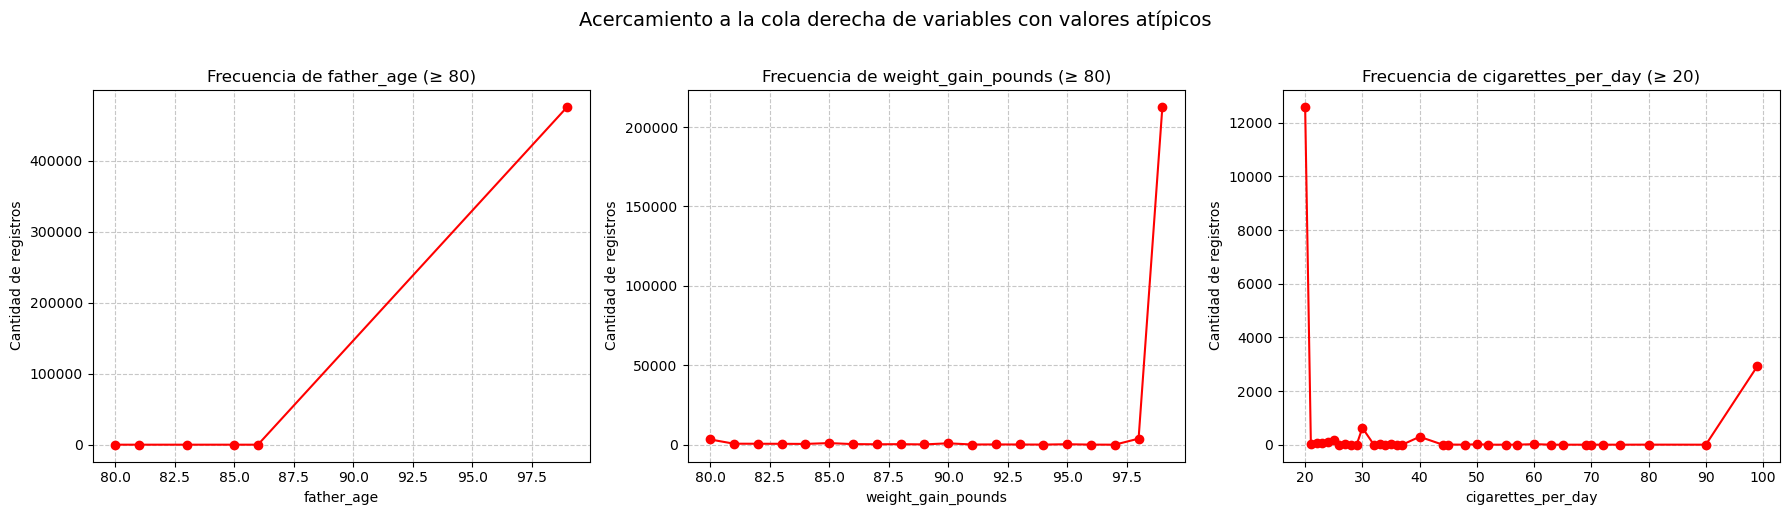

In [17]:
# --- Acercamiento (zoom) a la cola derecha de variables con valores atípicos ---

variables_zoom = {
    'father_age': 80,
    'weight_gain_pounds': 80,
    'cigarettes_per_day': 20,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (variable, umbral) in zip(axes, variables_zoom.items()):
    conteo = X_train[variable].dropna().value_counts().sort_index()
    conteo_zoom = conteo[conteo.index >= umbral]
    
    ax.plot(conteo_zoom.index, conteo_zoom.values, marker='o', linestyle='-', color='red')
    ax.set_title(f'Frecuencia de {variable} (≥ {umbral})')
    ax.set_xlabel(variable)
    ax.set_ylabel('Cantidad de registros')
    ax.grid(True, linestyle='--', alpha=0.7)

plt.suptitle('Acercamiento a la cola derecha de variables con valores atípicos', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Limpieza de datos

Los análisis anteriores permiten identificar varios aspectos relevantes:

1. Columnas sin información, en las que todos los registros son valores nulos (NaN).
2. Una columna redundante, como cigarette_use, que no aporta información adicional si ya se cuenta con la cantidad de cigarrillos consumidos por día.
3. Variables numéricas con valores atípicos, principalmente father_age, weight_gain_pounds y cigarettes_per_day. En la gráfica anterior se observa la presencia recurrente del valor 99, lo cual resulta inusual y sugiere un posible error de imputación. Estos valores serán reemplazados por la mediana calculada únicamente sobre el conjunto de entrenamiento, con el fin de evitar data leakage.


In [18]:
# Quitamos de X_train y X_test las columnas que no tienen información
cols_sin_info = ['born_alive_alive', 'born_alive_dead', 'born_dead', 'drinks_per_week', 'mother_residence_state', 'mother_birth_state', 'alcohol_use']
X_train = X_train.drop(columns=cols_sin_info)
X_test = X_test.drop(columns=cols_sin_info)

# Quitamos la columna cigarette_use porque en el fondo contiene la misma información que cigarettes_per_day (si fuma, cuántos cigarrillos fuma). Además, cigarette_use tiene muchos valores faltantes y es redundante con cigarettes_per_day. Al eliminarla, simplificamos el modelo sin perder información relevante.
X_train = X_train.drop(columns=['cigarette_use'])
X_test = X_test.drop(columns=['cigarette_use'])

cols_numericas = X_train.select_dtypes(include=[np.number]).columns.tolist()
cols_categoricas = X_train.select_dtypes(include=['category', 'object', 'bool']).columns.tolist()

In [19]:
# === PREPROCESAMIENTO ===

# 1. Convertir códigos 99 a NaN en variables con ese patrón de error
cols_99 = ['father_age', 'weight_gain_pounds', 'cigarettes_per_day']
for col in cols_99:
    X_train[col] = X_train[col].where(X_train[col] != 99, pd.NA)
    X_test[col] = X_test[col].where(X_test[col] != 99, pd.NA)

# 2. Imputar variables numéricas con la mediana del conjunto de entrenamiento
medianas = X_train[cols_numericas].median()
X_train[cols_numericas] = X_train[cols_numericas].fillna(medianas)
X_test[cols_numericas] = X_test[cols_numericas].fillna(medianas)

# 3. Imputar variables booleanas con False (NaN = desconocido → se asume ausencia)
cols_bool = X_train.select_dtypes(include=['bool', 'boolean']).columns.tolist()
for col in cols_bool:
    X_train[col] = X_train[col].fillna(False).astype('bool')
    X_test[col] = X_test[col].fillna(False).astype('bool')

# 4. Imputar variables categóricas con "Desconocido"
cols_cat = X_train.select_dtypes(include=['category']).columns.tolist()
for col in cols_cat:
    for df_part in [X_train, X_test]:
        if 'Desconocido' not in df_part[col].cat.categories:
            df_part[col] = df_part[col].cat.add_categories('Desconocido')
        df_part[col] = df_part[col].fillna('Desconocido')

# 5. Eliminar registros con nulos en la variable objetivo
mask_train = y_train.notna()
mask_test = y_test.notna()

X_train = X_train.loc[mask_train]
y_train = y_train.loc[mask_train]
X_test = X_test.loc[mask_test]
y_test = y_test.loc[mask_test]

# Verificación
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")
print(f"\nNulos restantes en X_train:\n{X_train.isnull().sum()}")
print(f"\nNulos en y_train: {y_train.isnull().sum()}")
print(f"Nulos en y_test:  {y_test.isnull().sum()}")

X_train: (3400650, 11) | y_train: (3400650,)
X_test:  (850141, 11)  | y_test:  (850141,)

Nulos restantes en X_train:
month                 0
is_male               0
plurality             0
mother_race           0
mother_age            0
gestation_weeks       0
mother_married        0
cigarettes_per_day    0
weight_gain_pounds    0
father_race           0
father_age            0
dtype: int64

Nulos en y_train: 0
Nulos en y_test:  0


### Análisis Multivariado

Se elaboran scatterplots y una matriz de correlación para analizar la relación entre las variables numéricas y la variable objetivo. Asimismo, se construyen boxplots agrupados para examinar la distribución de la variable objetivo en función de las variables categóricas.


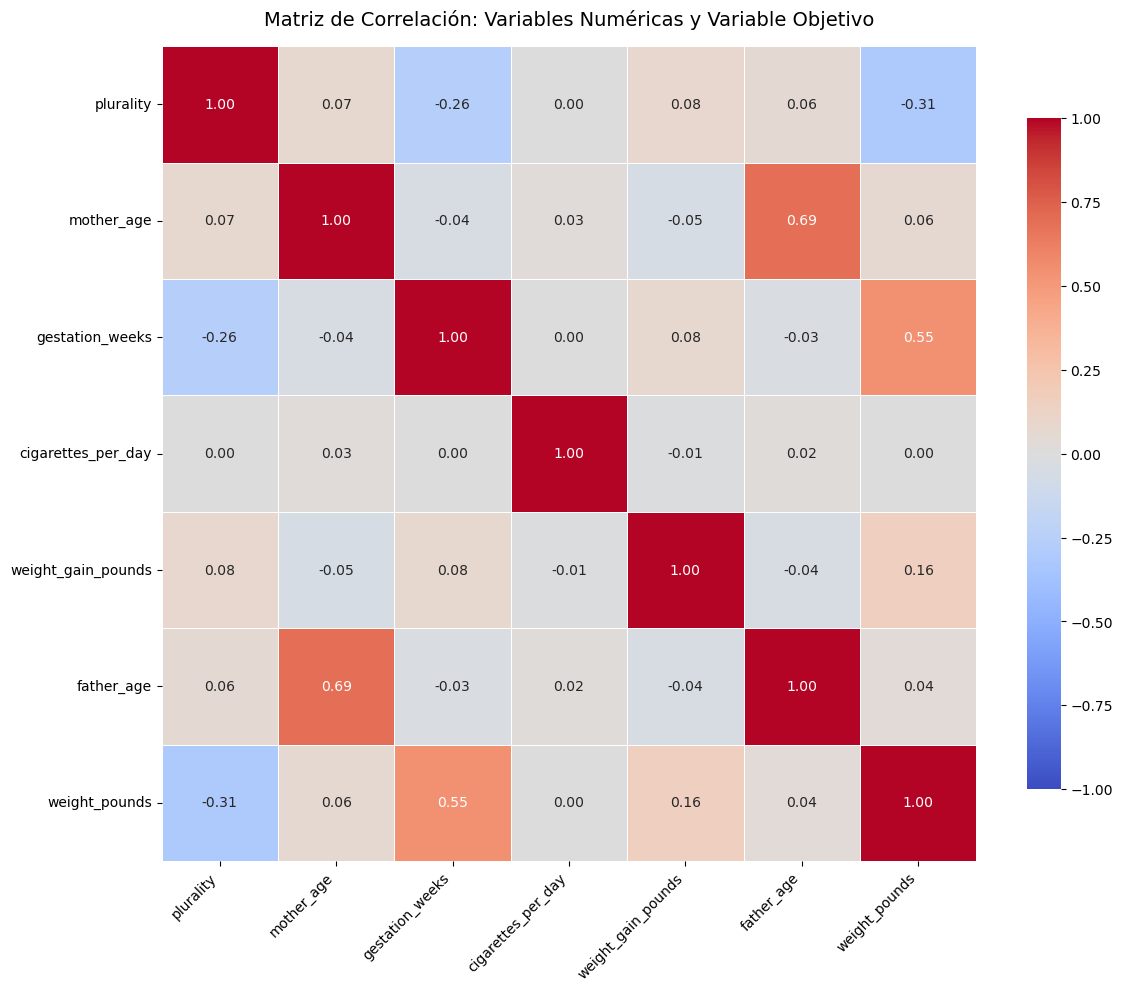

In [20]:
# Correlaciones

# Creamos una copia temporal para no alterar el X_train original
df_temp = X_train[cols_numericas].copy()

# Unimos la variable objetivo (y_train) al DataFrame temporal
df_temp['weight_pounds'] = y_train

# Calculamos la matriz de correlación 
matriz_corr = df_temp.corr()

# Configuramos el gráfico para que se vea amplio y bonito
plt.figure(figsize=(12, 10))

# Dibujamos el Heatmap
sns.heatmap(matriz_corr, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            vmin=-1, 
            vmax=1, 
            square=True, 
            linewidths=.5,
            cbar_kws={"shrink": .8}) 

plt.title('Matriz de Correlación: Variables Numéricas y Variable Objetivo', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()


Las mayores correlaciones con la variable objetivo se observan en las variables de pluralidad y semanas de gestación, y en menor medida en la ganancia de peso. Por otro lado, la edad de los padres y el consumo de cigarrillos no parecen tener un impacto significativo sobre el peso del bebé a primera vista.

## Relación entre Variables Numéricas y la Variable Objetivo


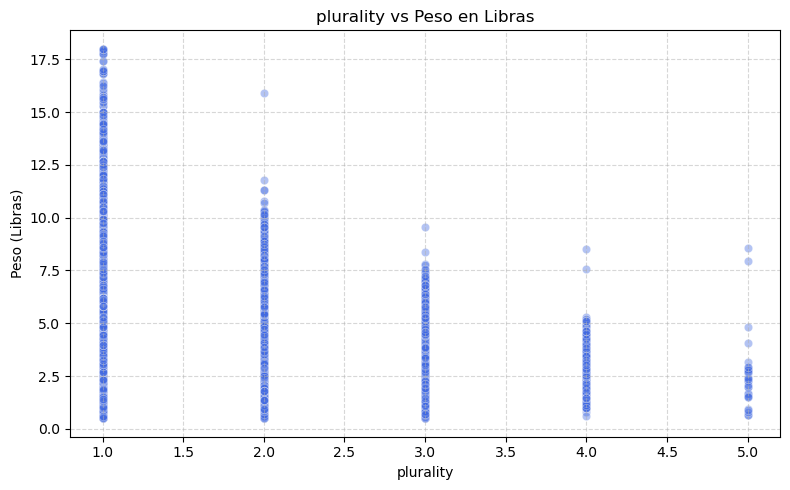

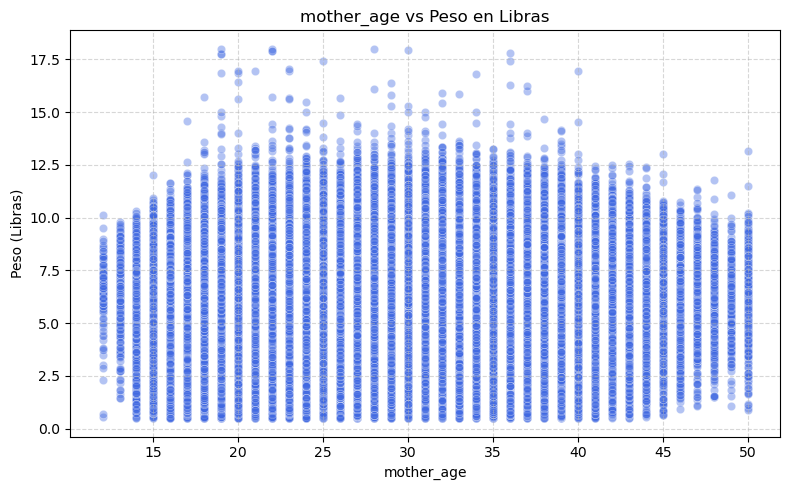

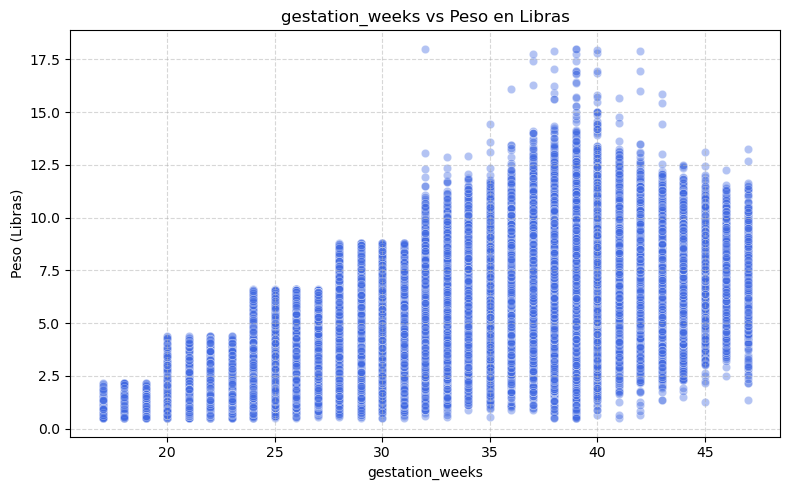

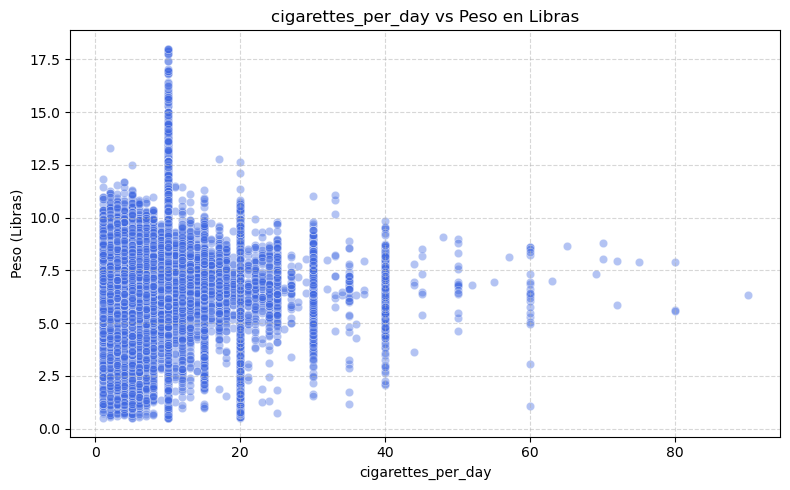

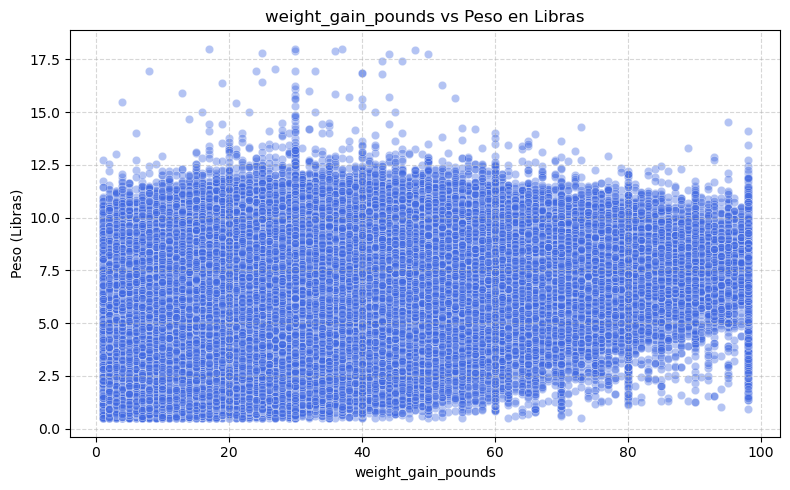

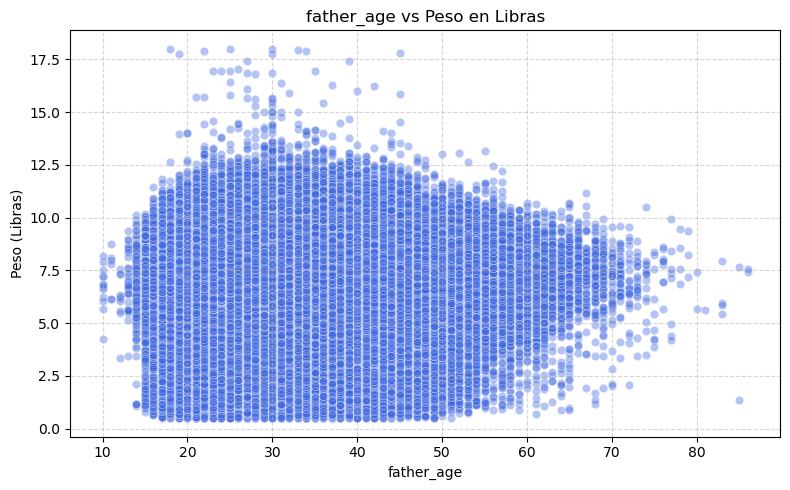

In [21]:
# Gráficos de dispersión para cada variable numérica vs la variable objetivo

print("## Relación entre Variables Numéricas y la Variable Objetivo")

# Iteramos directamente sobre la lista de columnas numéricas 
for col in cols_numericas:
    plt.figure(figsize=(8, 5))
    
    # Creamos el gráfico de dispersión
    sns.scatterplot(x=X_train[col], y=y_train, color='royalblue', alpha=0.4)

    plt.title(f'{col} vs Peso en Libras')
    plt.xlabel(col)
    plt.ylabel('Peso (Libras)')

    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

## Relación entre Variables Categóricas y la Variable Objetivo


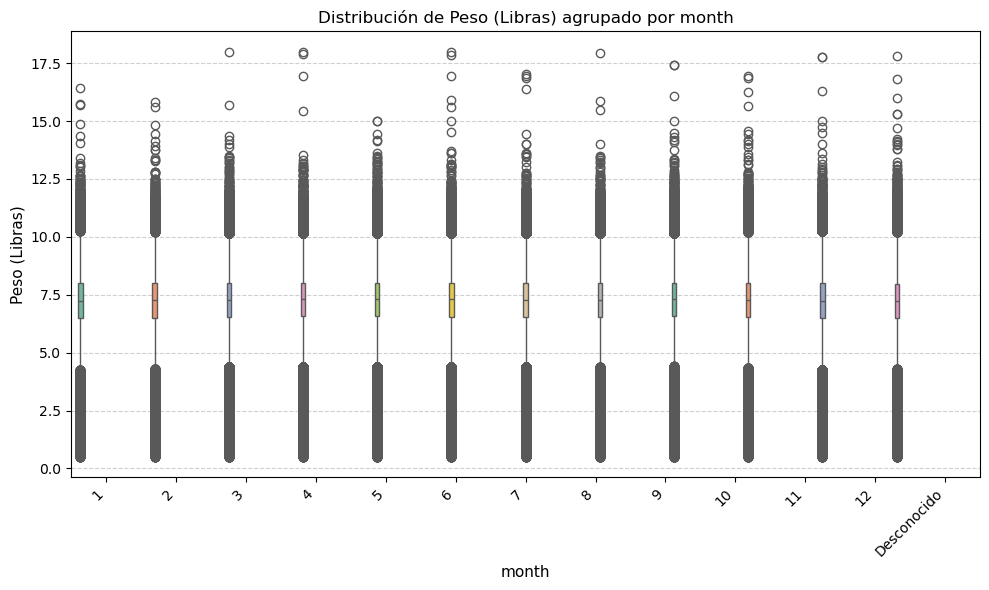

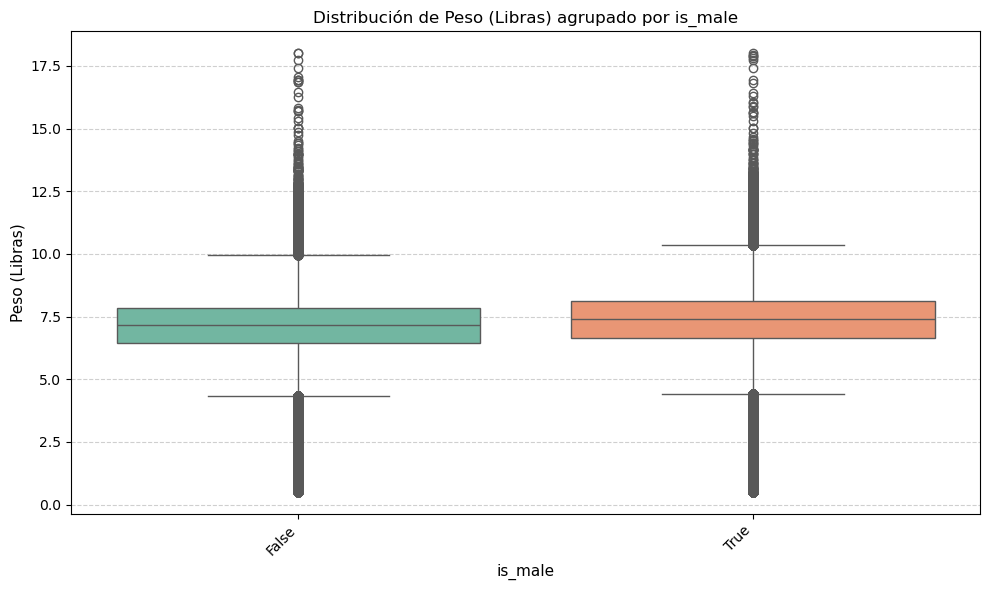

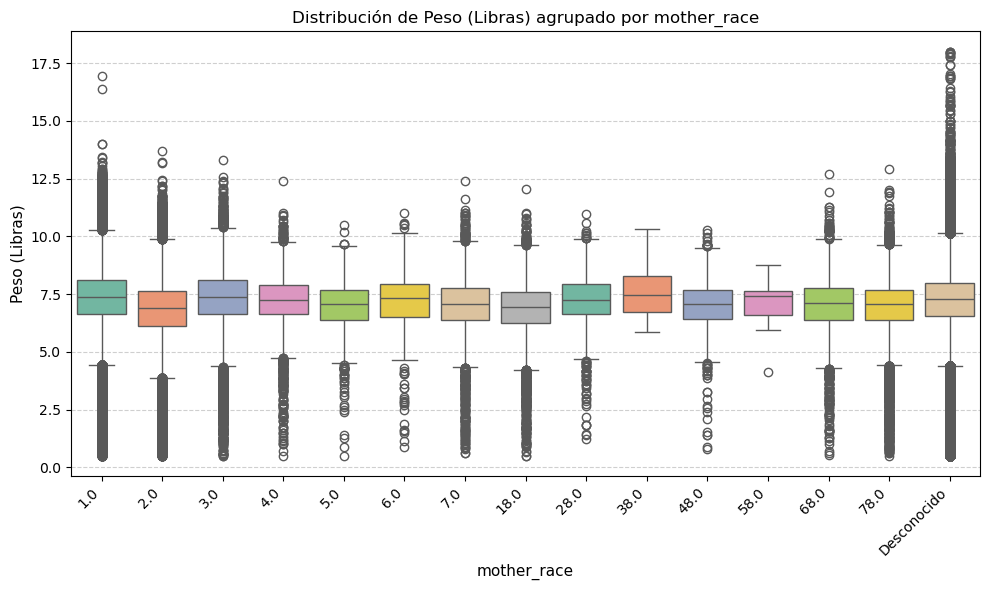

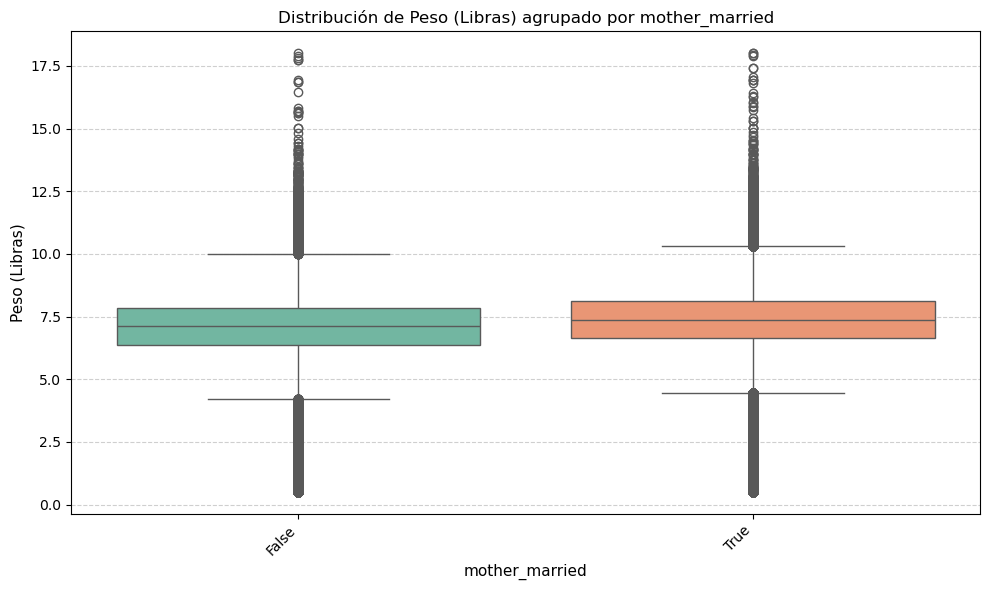

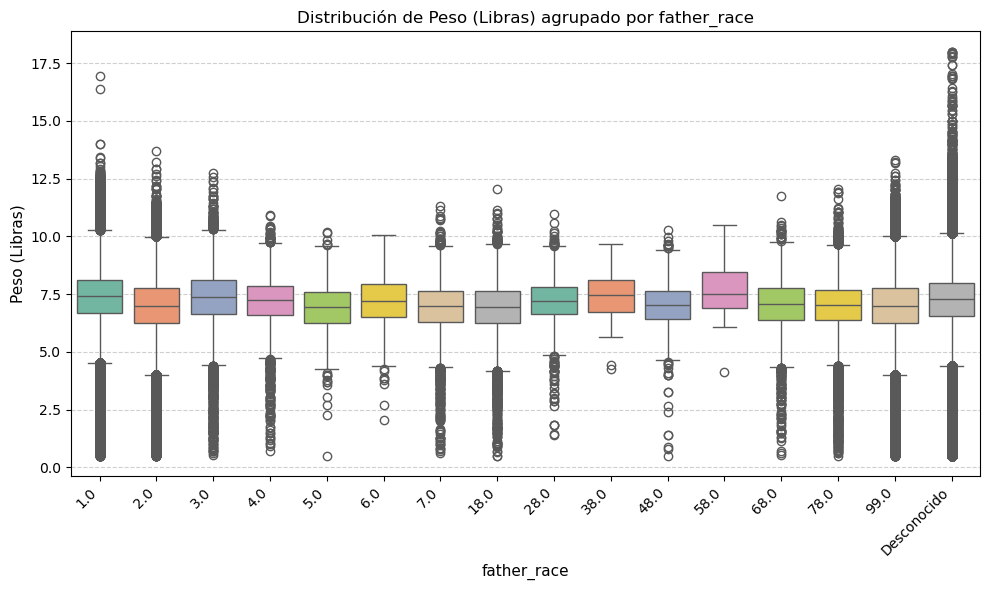

In [22]:
print("## Relación entre Variables Categóricas y la Variable Objetivo")

for col in cols_categoricas:
    plt.figure(figsize=(10, 6))
    
    # Creamos el boxplot usando la variable temporal 'datos_x'
    sns.boxplot(x=X_train[col], 
                y=y_train, 
                hue=X_train[col], 
                palette='Set2', 
                legend=False)
    
    plt.title(f'Distribución de Peso (Libras) agrupado por {col}', fontsize=12)
    plt.xlabel(col, fontsize=11)
    plt.ylabel('Peso (Libras)', fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

Se observa que, en promedio, los bebés de sexo masculino presentan un mayor peso al nacer en comparación con los de sexo femenino. Asimismo, se identifican algunas variaciones en el peso según la raza de los bebés.

## Modelos

Se prueban en este paso seis modelos. Uno por cada integrante del grupo. 

### Preparación de datos para modelos

Se aplicará one-hot encoding a las variables categóricas, se transformarán las variables booleanas en valores binarios (0 y 1) y se escalarán las variables numéricas utilizando StandardScaler de Scikit-learn.


In [24]:
# --- One-Hot Encoding de variables categóricas ---
cols_cat_encode = X_train.select_dtypes(include=['category']).columns.tolist()
cols_bool_encode = X_train.select_dtypes(include=['bool']).columns.tolist()

# One-hot encoding (drop_first para evitar multicolinealidad perfecta)
X_train_encoded = pd.get_dummies(X_train, columns=cols_cat_encode, drop_first=True, dtype=float)
for col in cols_bool_encode:
    X_train_encoded[col] = X_train_encoded[col].astype(float)
X_train_encoded = X_train_encoded.astype(float)

X_test_encoded = pd.get_dummies(X_test, columns=cols_cat_encode, drop_first=True, dtype=float)
for col in cols_bool_encode:
    X_test_encoded[col] = X_test_encoded[col].astype(float)
X_test_encoded = X_test_encoded.astype(float)

# Asegurar que test tenga las mismas columnas que train
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# --- Escalado de variables (StandardScaler ajustado solo en train) ---
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_encoded),
    columns=X_train_encoded.columns,
    index=X_train_encoded.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_encoded),
    columns=X_test_encoded.columns,
    index=X_test_encoded.index
)

print(f"Features después de encoding: {X_train_scaled.shape[1]}")
print(f"Columnas: {X_train_scaled.columns.tolist()}")

Features después de encoding: 49
Columnas: ['is_male', 'plurality', 'mother_age', 'gestation_weeks', 'mother_married', 'cigarettes_per_day', 'weight_gain_pounds', 'father_age', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12', 'month_Desconocido', 'mother_race_2.0', 'mother_race_3.0', 'mother_race_4.0', 'mother_race_5.0', 'mother_race_6.0', 'mother_race_7.0', 'mother_race_18.0', 'mother_race_28.0', 'mother_race_38.0', 'mother_race_48.0', 'mother_race_58.0', 'mother_race_68.0', 'mother_race_78.0', 'mother_race_Desconocido', 'father_race_2.0', 'father_race_3.0', 'father_race_4.0', 'father_race_5.0', 'father_race_6.0', 'father_race_7.0', 'father_race_18.0', 'father_race_28.0', 'father_race_38.0', 'father_race_48.0', 'father_race_58.0', 'father_race_68.0', 'father_race_78.0', 'father_race_99.0', 'father_race_Desconocido']


### 1. Regresión Lineal con Stepwise (Modelo base)

El modelo base es una regresión lineal. A esta se le aplica el método Stepwise de feature selection para obtener las variables más relevantes en la regresión y evitar el sobreajuste (overfitting) resultante de incluir información redundante o ruidosa. Este proceso de selección se llevará a cabo mediante una muestra aleatoria de 500,000 registros, para identificar los predictores clave sin incurrir en los excesivos tiempos de procesamiento que requeriría el algoritmo iterativo sobre el dataset completo. Una vez identificada la combinación óptima de variables bajo el criterio de información de Akaike (AIC), el modelo definitivo se ajustará utilizando la totalidad de los 3.4 millones de registros para maximizar la precisión y robustez de los coeficientes finales.

In [26]:
# === STEPWISE FORWARD SELECTION ===
np.random.seed(SEED)
sample_idx = np.random.choice(X_train_scaled.index, size=500_000, replace=False)
X_sample = X_train_scaled.loc[sample_idx]
y_sample = y_train.loc[sample_idx]

def forward_stepwise_aic(X, y):
    """
    Selección forward basada puramente en la reducción del AIC.
    Se detiene cuando añadir una nueva variable ya no disminuye el AIC actual.
    """
    variables_disponibles = list(X.columns)
    variables_seleccionadas = []
    
    # Empezamos con un modelo base (solo la constante) para tener un AIC inicial
    X_inicial = sm.add_constant(pd.DataFrame(np.ones((len(y), 1)), index=y.index))
    mejor_aic = sm.OLS(y, X_inicial).fit().aic
    
    historial = []
    
    print(f"AIC inicial (modelo nulo): {mejor_aic:.2f}")
    print("-" * 90)

    while variables_disponibles:
        aic_paso = []
        
        # Probamos todas las variables restantes una por una
        for var in variables_disponibles:
            candidatas = variables_seleccionadas + [var]
            X_candidata = sm.add_constant(X[candidatas])
            modelo = sm.OLS(y, X_candidata).fit()
            aic_paso.append((modelo.aic, var))
        
        # Ordenamos para encontrar la que más reduce el AIC
        aic_paso.sort()
        mejor_aic_candidato, mejor_var_candidata = aic_paso[0]
        
        # Criterio de parada: ¿El nuevo AIC es menor que el que ya teníamos?
        if mejor_aic_candidato < mejor_aic:
            variables_seleccionadas.append(mejor_var_candidata)
            variables_disponibles.remove(mejor_var_candidata)
            mejor_aic = mejor_aic_candidato
            
            # Guardamos métricas del nuevo modelo ganador de este paso
            X_actual = sm.add_constant(X[variables_seleccionadas])
            res = sm.OLS(y, X_actual).fit()
            
            historial.append({
                'Paso': len(variables_seleccionadas),
                'Variable añadida': mejor_var_candidata,
                'AIC': res.aic,
                'R²_adj': res.rsquared_adj,
                'p-valor_var': res.pvalues[mejor_var_candidata]
            })
            
            print(f"Paso {len(variables_seleccionadas):2d}: + {mejor_var_candidata:<30s} | AIC={res.aic:.2f} | Δ_AIC={mejor_aic_candidato - historial[-2]['AIC'] if len(historial)>1 else mejor_aic_candidato - mejor_aic:.2f}")
        else:
            print(f"\nParada: Añadir más variables no reduce el AIC (Mejor AIC alcanzado: {mejor_aic:.2f})")
            break
            
    return variables_seleccionadas, pd.DataFrame(historial)

print("=" * 90)
print("FORWARD STEPWISE SELECTION (Muestra: 500k, Criterio: AIC)")
print("=" * 90)
variables_stepwise_aic, historial_aic = forward_stepwise_aic(X_sample, y_sample)

print(f"\nVariables seleccionadas por AIC ({len(variables_stepwise_aic)}):")
for i, v in enumerate(variables_stepwise_aic, 1):
    print(f"  {i}. {v}")

FORWARD STEPWISE SELECTION (Muestra: 500k, Criterio: AIC)
AIC inicial (modelo nulo): 1685672.88
------------------------------------------------------------------------------------------
Paso  1: + gestation_weeks                | AIC=1508304.67 | Δ_AIC=0.00
Paso  2: + plurality                      | AIC=1486833.00 | Δ_AIC=-21471.67
Paso  3: + weight_gain_pounds             | AIC=1473247.19 | Δ_AIC=-13585.81
Paso  4: + mother_age                     | AIC=1464767.37 | Δ_AIC=-8479.81
Paso  5: + is_male                        | AIC=1457005.01 | Δ_AIC=-7762.36
Paso  6: + mother_married                 | AIC=1453831.66 | Δ_AIC=-3173.36
Paso  7: + mother_race_2.0                | AIC=1452481.32 | Δ_AIC=-1350.34
Paso  8: + mother_race_78.0               | AIC=1452217.20 | Δ_AIC=-264.12
Paso  9: + father_race_Desconocido        | AIC=1451936.63 | Δ_AIC=-280.56
Paso 10: + father_race_18.0               | AIC=1451685.09 | Δ_AIC=-251.55
Paso 11: + father_race_7.0                | AIC=1451574.89

In [27]:
# === MODELO FINAL: Regresión Lineal con variables seleccionadas por Stepwise ===

# Ajustar modelo final con TODOS los datos de entrenamiento y las variables seleccionadas
X_train_sw = sm.add_constant(X_train_scaled[variables_stepwise_aic])
X_test_sw = sm.add_constant(X_test_scaled[variables_stepwise_aic])

modelo_ols_stepwise = sm.OLS(y_train, X_train_sw).fit()

# Resumen del modelo
print(modelo_ols_stepwise.summary())

                            OLS Regression Results                            
Dep. Variable:          weight_pounds   R-squared:                       0.374
Model:                            OLS   Adj. R-squared:                  0.374
Method:                 Least Squares   F-statistic:                 6.168e+04
Date:                Wed, 01 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:38:56   Log-Likelihood:            -4.9331e+06
No. Observations:             3400650   AIC:                         9.866e+06
Df Residuals:                 3400616   BIC:                         9.867e+06
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

Se evalúa el modelo en la base de datos de test y se hacen las gráficas de análisis de sus errores. 

MÉTRICAS - REGRESIÓN LINEAL STEPWISE
  Modelo         : Regresión Lineal (Stepwise)
  R² Train       : 0.374445
  R² Test        : 0.372878
  RMSE Train     : 1.032200
  RMSE Test      : 1.032002
  MAE Train      : 0.799884
  MAE Test       : 0.799153
  Variables      : 33


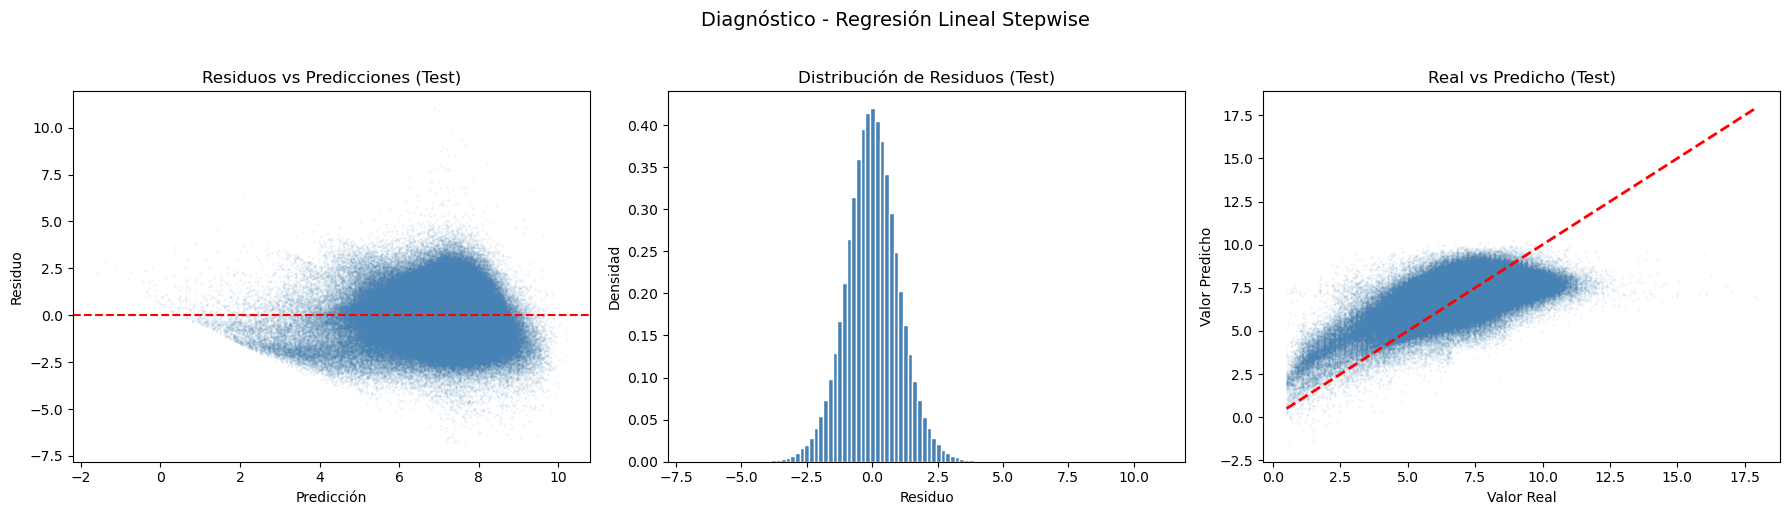

In [29]:
# === EVALUACIÓN: Regresión Lineal Stepwise ===

# Predicciones
y_train_pred_sw = modelo_ols_stepwise.predict(X_train_sw)
y_test_pred_sw = modelo_ols_stepwise.predict(X_test_sw)

# Métricas
metricas_sw = {
    'Modelo': 'Regresión Lineal (Stepwise)',
    'R² Train': r2_score(y_train, y_train_pred_sw),
    'R² Test': r2_score(y_test, y_test_pred_sw),
    'RMSE Train': np.sqrt(mean_squared_error(y_train, y_train_pred_sw)),
    'RMSE Test': np.sqrt(mean_squared_error(y_test, y_test_pred_sw)),
    'MAE Train': mean_absolute_error(y_train, y_train_pred_sw),
    'MAE Test': mean_absolute_error(y_test, y_test_pred_sw),
    'Variables': len(variables_stepwise_aic),
}

print("=" * 60)
print("MÉTRICAS - REGRESIÓN LINEAL STEPWISE")
print("=" * 60)
for k, v in metricas_sw.items():
    if isinstance(v, float):
        print(f"  {k:<15s}: {v:.6f}")
    else:
        print(f"  {k:<15s}: {v}")

# --- Gráficos de diagnóstico ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

residuos_test = y_test.values - y_test_pred_sw.values

# 1. Residuos vs Predicciones
axes[0].scatter(y_test_pred_sw, residuos_test, alpha=0.05, s=1, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Residuo')
axes[0].set_title('Residuos vs Predicciones (Test)')

# 2. Distribución de residuos
axes[1].hist(residuos_test, bins=100, color='steelblue', edgecolor='white', density=True)
axes[1].set_xlabel('Residuo')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución de Residuos (Test)')

# 3. Real vs Predicho
axes[2].scatter(y_test, y_test_pred_sw, alpha=0.05, s=1, color='steelblue')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_xlabel('Valor Real')
axes[2].set_ylabel('Valor Predicho')
axes[2].set_title('Real vs Predicho (Test)')

plt.suptitle('Diagnóstico - Regresión Lineal Stepwise', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2-6. Modelos más avanzadps
Aquí se emplearán técnicas como Ensambles, Redes Neuronales o regularización con Redes Elásticas

In [34]:
# Diccionario para guardar los resultados de los modelos
results={}

#### Pipeline de Preprocesamiento Centralizado

Este bloque de código establece un pipeline de preprocesamiento centralizado. En primer lugar, realiza una limpieza al convertir variables booleanas a enteros y forzar las categóricas a formato de texto, lo que previene errores comunes de tipos mezclados durante la codificación. Posteriormente, utiliza un ColumnTransformer para aplicar dos procesos fundamentales: la estandarización y la codificación One-Hot.

Un aspecto crítico de esta implementación es que el ajuste de los parámetros (fit) se realiza exclusivamente sobre el conjunto de entrenamiento, mientras que al conjunto de prueba solo se le aplica la transformación; esta práctica es vital para evitar el data leakage y garantizar una evaluación realista del modelo. Finalmente, el código optimiza el uso de memoria al convertir los resultados a float32, una precisión adecuada para algoritmos de Machine Learning que acelera el procesamiento, y extrae los nombres definitivos de las características para permitir una interpretación clara en análisis posteriores de explicabilidad como SHAP.

In [31]:
# === PIPELINE DE PREPROCESAMIENTO CENTRALIZADO ===

cols_num_ml  = X_train.select_dtypes(include=[np.number]).columns.tolist()
cols_cat_ml  = X_train.select_dtypes(include=['category']).columns.tolist()
cols_bool_ml = X_train.select_dtypes(include=['bool']).columns.tolist()

# Bool -> int8 para compatibilidad con sklearn
X_train_ml = X_train.copy()
X_test_ml  = X_test.copy()
for col in cols_bool_ml:
    X_train_ml[col] = X_train_ml[col].astype(np.int8)
    X_test_ml[col]  = X_test_ml[col].astype(np.int8)

# Categóricas -> str para evitar mezcla float/str en las categorías
# (ocurre cuando los códigos originales son numéricos y la imputación añade 'Desconocido')
for col in cols_cat_ml:
    X_train_ml[col] = X_train_ml[col].astype(str)
    X_test_ml[col]  = X_test_ml[col].astype(str)

cols_num_ext = cols_num_ml + cols_bool_ml  # bool tratadas como numéricas

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), cols_num_ext),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=np.float32), cols_cat_ml)
    ],
    remainder='drop'
)

# Ajustar SOLO en train, transformar ambos (anti data-leakage)
X_train_proc = preprocessor.fit_transform(X_train_ml).astype(np.float32)
X_test_proc  = preprocessor.transform(X_test_ml).astype(np.float32)

# Variables objetivo como float32
y_train_np = y_train.values.astype(np.float32)
y_test_np  = y_test.values.astype(np.float32)

# Nombres de features para SHAP (se usan en la sección de explicabilidad)
feature_names = [n.split('__', 1)[-1] for n in preprocessor.get_feature_names_out()]


#### 2. XGBoost Regressor

En esta sección se implementa el modelo Extreme Gradient Boosting (XGBoost). Dada la magnitud del conjunto de datos, la arquitectura del código está diseñada para maximizar la eficiencia computacional. El flujo de trabajo consta de las siguientes fases:

1. **Aceleración por Hardware:** Se configura el algoritmo para aprovechar la paralelización de la tarjeta gráfica (GPU) mediante los parámetros tree_method='hist' y device='cuda, lo que reduce drásticamente los tiempos de procesamiento.
2. **Búsqueda Estocástica de Hiperparámetros (Random Search):** En lugar de realizar una búsqueda de grilla exhaustiva, se evalúan combinaciones aleatorias de hiperparámetros sobre una submuestra representativa del 25% de los datos. Esta estrategia permite identificar zonas óptimas del espacio de parámetros de forma ágil.
3. **Validación Cruzada Robusta (5-Fold CV):** Para cada configuración candidata, se aplica validación cruzada de 5 pliegues (k-fold cross-validation). Esto garantiza que las métricas de error (RMSE) sean estables y no dependan de una partición de datos particular. Se incluye *Early Stopping* para mitigar el sobreajuste (overfitting).
4. **Entrenamiento Definitivo:** Una vez identificada la configuración ganadora, el modelo final se entrena utilizando el 100% del conjunto de entrenamiento para capturar todos los patrones de la población. Finalmente, se extraen las métricas de rendimiento (RMSE, MAE y R²) sobre el conjunto de prueba aislado.

In [36]:
# === XGBOOST REGRESSOR (GPU RTX 4050) CON BÚSquEDA DE HIPERPARÁMETROS ===
print('=' * 60)
print('2. XGBoost Regressor (GPU RTX 4050)')
print('=' * 60)
t0 = time.time()

# Muestra del 25% para búsqueda de hiperparámetros
np.random.seed(SEED)
sample_size   = int(0.25 * X_train_proc.shape[0])
sample_idx    = np.random.choice(X_train_proc.shape[0], size=sample_size, replace=False)
X_xgb_sample  = X_train_proc[sample_idx]
y_xgb_sample  = y_train_np[sample_idx]
dtrain_sample = xgb.DMatrix(X_xgb_sample, label=y_xgb_sample)

xgb_param_dist = {
    'max_depth':        [6, 8, 10],
    'learning_rate':    [0.05, 0.1, 0.15],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}
param_configs = list(ParameterSampler(xgb_param_dist, n_iter=10, random_state=42))

best_xgb_rmse   = float('inf')
best_xgb_params = param_configs[0]
best_xgb_iter   = 100

print(f'Buscando hiperparámetros en {sample_size:,} filas (25%)...')
for i, params in enumerate(param_configs):
    hp = {'objective': 'reg:squarederror', 'tree_method': 'hist',
          'device': 'cuda', 'eval_metric': 'rmse', **params}
    cv_res  = xgb.cv(params=hp, dtrain=dtrain_sample, num_boost_round=500,
                     nfold=5, early_stopping_rounds=30, seed=SEED, verbose_eval=False)
    rmse_cv = float(cv_res['test-rmse-mean'].min())
    iter_cv = int(cv_res['test-rmse-mean'].idxmin())
    if rmse_cv < best_xgb_rmse:
        best_xgb_rmse, best_xgb_params, best_xgb_iter = rmse_cv, params, iter_cv
    print(f'  Config {i+1:02d}/{len(param_configs)}: RMSE={rmse_cv:.4f} | {params}')

print(f'\nMejor config: {best_xgb_params}')
print(f'Mejor RMSE CV (muestra): {best_xgb_rmse:.4f} | Iteraciones: {best_xgb_iter}')

# Entrenamiento final con 100% de los datos
print('\nEntrenando XGBoost final en 100% de los datos...')
dtrain_full = xgb.DMatrix(X_train_proc, label=y_train_np)
dtest_full  = xgb.DMatrix(X_test_proc,  label=y_test_np)

final_params = {'objective': 'reg:squarederror', 'tree_method': 'hist',
                'device': 'cuda', 'eval_metric': 'rmse', **best_xgb_params}

xgb_model = xgb.train(
    final_params, dtrain_full,
    num_boost_round=best_xgb_iter + 1,
    evals=[(dtrain_full, 'train'), (dtest_full, 'test')],
    verbose_eval=100
)


2. XGBoost Regressor (GPU RTX 4050)
Buscando hiperparámetros en 850,162 filas (15%)...
  Config 01/10: RMSE=0.9940 | {'subsample': 0.7, 'min_child_weight': 5, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
  Config 02/10: RMSE=0.9929 | {'subsample': 0.7, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
  Config 03/10: RMSE=0.9937 | {'subsample': 0.9, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.15, 'colsample_bytree': 0.8}
  Config 04/10: RMSE=0.9939 | {'subsample': 0.8, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.15, 'colsample_bytree': 1.0}
  Config 05/10: RMSE=0.9952 | {'subsample': 0.8, 'min_child_weight': 3, 'max_depth': 10, 'learning_rate': 0.15, 'colsample_bytree': 1.0}
  Config 06/10: RMSE=0.9934 | {'subsample': 0.8, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
  Config 07/10: RMSE=0.9948 | {'subsample': 0.9, 'min_child_weight': 5, 'max_depth': 10, 'learn

In [37]:
y_pred_xgb = xgb_model.predict(dtest_full)
results['XGBoost'] = {
    'RMSE': float(np.sqrt(mean_squared_error(y_test_np, y_pred_xgb))),
    'MAE':  float(mean_absolute_error(y_test_np, y_pred_xgb)),
    'R2':   float(r2_score(y_test_np, y_pred_xgb)),
    'preds': y_pred_xgb
}
print(f"\nXGBoost \u2192 RMSE: {results['XGBoost']['RMSE']:.4f} | "
      f"MAE: {results['XGBoost']['MAE']:.4f} | R\u00b2: {results['XGBoost']['R2']:.4f}")
print(f'Tiempo total: {(time.time()-t0)/60:.1f} min')


XGBoost → RMSE: 0.9918 | MAE: 0.7665 | R²: 0.4207
Tiempo total: 5.4 min


#### 3. Red Neuronal Profunda

| Capa | Neuronas | Activación | Regularización |
|------|----------|------------|----------------|
| 1    | 256      | LeakyReLU  | BatchNorm + Dropout 30% |
| 2    | 128      | LeakyReLU  | BatchNorm + Dropout 20% |
| 3    | 64       | LeakyReLU  | BatchNorm |
| Salida | 1     | Lineal     | — |

- **Optimizador**: AdamW (lr=0.005, weight_decay=1e-4)
- **Scheduler**: ReduceLROnPlateau (factor=0.5, patience=3)
- **Batch size**: 4096

La arquitectura descrita corresponde a un Perceptrón Multicapa (MLP) profundo con estructura de "embudo" (reducción progresiva de dimensiones). Para ejecutar este modelo sobre un conjunto de datos masivo (más de 3.4 millones de registros) utilizando aceleración por GPU (CUDA), el código implementa las siguientes estrategias técnicas:

Inicialización Kaiming: Los pesos de las capas lineales se inicializan mediante el método kaiming_normal_. Esta técnica está matemáticamente optimizada para funciones de activación asimétricas como LeakyReLU, evitando el problema de la desaparición del gradiente en las primeras fases del entrenamiento.

Pipeline Anti-Cuello de Botella (I/O): Para evitar desbordamientos de memoria de video (OOM), los tensores principales residen en la memoria RAM del sistema. El DataLoader utiliza el parámetro pin_memory=True para crear un canal directo y rápido hacia la GPU, enviando dinámicamente lotes masivos de 4096 registros (batch_size=4096) solo en el instante exacto en que la tarjeta gráfica los necesita procesar.

Regularización Híbrida: Se emplea una combinación simultánea de Batch Normalization (para estabilizar y acelerar la convergencia re-escalando las activaciones internas) y Dropout (para prevenir el sobreajuste al desactivar aleatoriamente un porcentaje de neuronas, forzando a la red a no depender de rutas específicas).

Optimización Dinámica y Early Stopping Lógico: El entrenamiento es guiado por el optimizador AdamW, que aplica un decaimiento de pesos (weight decay) superior al Adam tradicional para mejorar la generalización. Además, el planificador de tasa de aprendizaje (ReduceLROnPlateau) monitorea rigurosamente el error de validación al final de cada época. Si la métrica se estanca durante dos épocas (patience=2), el planificador reduce la tasa de aprendizaje a la mitad (factor=0.5), permitiendo un ajuste fino de los pesos en las etapas finales del entrenamiento.

Inferencia Segura: A diferencia de las implementaciones básicas, la fase de evaluación sobre el conjunto de prueba (X_test_proc) también se realiza mediante procesamiento por lotes dentro de un entorno torch.no_grad(). Esto garantiza que la memoria de la GPU no colapse al calcular el RMSE, MAE y R² finales.

In [38]:
# 1. Definir la variable device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Imprimir los resultados de diagnóstico
print(f"Versión de PyTorch: {torch.__version__}")
print(f"¿CUDA disponible?: {torch.cuda.is_available()}")
print(f"¿Por qué no?: {torch.cuda.is_available() == False}") # Si es False, es que falta el driver o el toolkit
print(f"Dispositivo que se usará: {device}")

if torch.cuda.is_available():
    print(f"Nombre de la GPU: {torch.cuda.get_device_name(0)}")

Versión de PyTorch: 2.7.1+cu118
¿CUDA disponible?: True
¿Por qué no?: False
Dispositivo que se usará: cuda
Nombre de la GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [39]:
# 1. Crear datasets 
X_train_t = torch.FloatTensor(X_train_proc)
y_train_t = torch.FloatTensor(y_train_np).view(-1, 1)
X_test_t  = torch.FloatTensor(X_test_proc)
y_test_t  = torch.FloatTensor(y_test_np).view(-1, 1)

# DataLoader configurad
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=4096, shuffle=True, pin_memory=True)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=4096, shuffle=False, pin_memory=True)

print(f'Dispositivo:    {device}')
print(f'Train samples:  {len(X_train_t):,} | Batches por época: {len(train_loader):,}')
print(f'Input features: {X_train_proc.shape[1]}')
print('DataLoader configurado para máxima velocidad (Batch: 4096).')

class BabyNetPro(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.01), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.LeakyReLU(0.01), nn.Dropout(0.2),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.LeakyReLU(0.01),
            nn.Linear(64, 1)
        )
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')

    def forward(self, x):
        return self.net(x)

t0        = time.time()
model_pro = BabyNetPro(X_train_proc.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model_pro.parameters(), lr=0.005, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

print('\nIniciando entrenamiento BabyNet Pro (30 épocas con Validación)...')

EPOCHS = 30
for epoch in range(EPOCHS):
    # --- FASE DE ENTRENAMIENTO ---
    model_pro.train()
    train_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        loss = criterion(model_pro(batch_x), batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_x.size(0)
    
    avg_train_loss = train_loss / len(train_loader.dataset)
    
    # --- FASE DE VALIDACIÓN (Clave para que el Scheduler frene a tiempo) ---
    model_pro.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x_val, batch_y_val in test_loader:
            batch_x_val, batch_y_val = batch_x_val.to(device), batch_y_val.to(device)
            v_loss = criterion(model_pro(batch_x_val), batch_y_val)
            val_loss += v_loss.item() * batch_x_val.size(0)
            
    avg_val_loss = val_loss / len(test_loader.dataset)
    
    # El scheduler actualiza el Learning Rate basado en datos de validación
    scheduler.step(avg_val_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:02d}/{EPOCHS} | Train RMSE: {np.sqrt(avg_train_loss):.4f} | '
              f'Val RMSE: {np.sqrt(avg_val_loss):.4f} | LR: {optimizer.param_groups[0]["lr"]:.6f}')

# --- EVALUACIÓN FINAL SEGURA (Procesamiento por lotes) ---
model_pro.eval()
nn_preds_list = []
with torch.no_grad():
    for batch_x_val, _ in test_loader:
        batch_x_val = batch_x_val.to(device)
        preds = model_pro(batch_x_val).cpu().numpy().flatten()
        nn_preds_list.extend(preds)

nn_preds = np.array(nn_preds_list)

results['RedNeuronal'] = {
    'RMSE': float(np.sqrt(mean_squared_error(y_test_np, nn_preds))),
    'MAE':  float(mean_absolute_error(y_test_np, nn_preds)),
    'R2':   float(r2_score(y_test_np, nn_preds)),
    'preds': nn_preds
}
print(f"\nRed Neuronal → RMSE: {results['RedNeuronal']['RMSE']:.4f} | "
      f"MAE: {results['RedNeuronal']['MAE']:.4f} | R²: {results['RedNeuronal']['R2']:.4f}")
print(f'Tiempo total: {(time.time()-t0)/60:.1f} min')

Dispositivo:    cuda
Train samples:  3,400,650 | Batches por época: 831
Input features: 51
DataLoader configurado para máxima velocidad (Batch: 4096).

Iniciando entrenamiento BabyNet Pro (30 épocas con Validación)...
Epoch 01/30 | Train RMSE: 1.3527 | Val RMSE: 0.9974 | LR: 0.005000
Epoch 05/30 | Train RMSE: 1.0005 | Val RMSE: 0.9958 | LR: 0.005000
Epoch 10/30 | Train RMSE: 0.9972 | Val RMSE: 0.9937 | LR: 0.002500
Epoch 15/30 | Train RMSE: 0.9966 | Val RMSE: 0.9932 | LR: 0.001250
Epoch 20/30 | Train RMSE: 0.9955 | Val RMSE: 0.9927 | LR: 0.001250
Epoch 25/30 | Train RMSE: 0.9947 | Val RMSE: 0.9926 | LR: 0.000313
Epoch 30/30 | Train RMSE: 0.9944 | Val RMSE: 0.9926 | LR: 0.000313

Red Neuronal → RMSE: 0.9926 | MAE: 0.7674 | R²: 0.4199
Tiempo total: 20.1 min


#### 4. Elastic Net (Regularización L1 + L2)

Este modelo es una regresión lineal en la que se aplica regularización por medio de redes elásticas. La Elastic Net combina Lasso (L1, selección de variables) y Ridge (L2, contracción de coeficientes). 

Las decisiones técnicas  en esta fase incluyen:

* **Búsqueda Dinámica de Hiperparámetros:** El modelo evalúa 8 balances distintos entre L1 y L2, abarcando desde una mezcla dominante de Ridge hasta el escenario de Lasso puro (1.0).
* **Validación Cruzada Integral:** Gracias a la eficiencia de esta implementación, la validación de 5 pliegues (*5-Fold CV*) se ejecuta sobre la totalidad del conjunto de entrenamiento.

In [49]:
# === ELASTIC NET CON ElasticNetCV (5-FOLD) ===
print('=' * 60)
print('4. Elastic Net (L1+L2) - ElasticNetCV')
print('=' * 60)
t0 = time.time()

# Instanciamos ElasticNetCV con una lista estratégica de l1_ratios
# n_alphas=100 le dice al algoritmo que genere automáticamente 100 valores de alpha a probar
en_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0], 
    n_alphas=50, 
    cv=5, 
    max_iter=3000,
    n_jobs=6, 
    precompute=False,
    random_state=42, 
    verbose=1
)

print(f"Iniciando ElasticNetCV en el 100% de los datos ({X_train_proc.shape[0]:,} filas)...")
# Al hacer .fit() aquí, se hace la validación cruzada Y el entrenamiento definitivo
en_cv.fit(X_train_proc, y_train_np)

best_alpha    = en_cv.alpha_
best_l1_ratio = en_cv.l1_ratio_
print(f'\nMejor alpha={best_alpha:.5f}, l1_ratio={best_l1_ratio:.4f}')

# Predecimos directamente usando el objeto en_cv (ya está entrenado con los 3.4M de datos)
y_pred_en = en_cv.predict(X_test_proc)

results['ElasticNet'] = {
    'RMSE': float(np.sqrt(mean_squared_error(y_test_np, y_pred_en))),
    'MAE':  float(mean_absolute_error(y_test_np, y_pred_en)),
    'R2':   float(r2_score(y_test_np, y_pred_en)),
    'preds': y_pred_en
}
print(f"ElasticNet \u2192 RMSE: {results['ElasticNet']['RMSE']:.4f} | "
      f"MAE: {results['ElasticNet']['MAE']:.4f} | R\u00b2: {results['ElasticNet']['R2']:.4f}")
print(f'Tiempo total: {(time.time()-t0)/60:.1f} min')

4. Elastic Net (L1+L2) - ElasticNetCV
Iniciando ElasticNetCV en el 100% de los datos (3,400,650 filas)...


[Parallel(n_jobs=6)]: Using backend ThreadingBackend with 6 concurrent workers.
........................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................


Mejor alpha=0.00071, l1_ratio=1.0000
ElasticNet → RMSE: 1.0323 | MAE: 0.7994 | R²: 0.3726
Tiempo total: 24.1 min


#### 5. Random Forest en GPU (XGBoost RF)

XGBRFRegressor implementa Random Forest usando el motor de XGBoost, lo que permite ejecutarlo en GPU. La fracción subsample=0.632 replica el bootstrap clásico. En este modelo se realizan las siguientes configuraciones: 

- **Búsqueda**: ParameterSampler (8 configs) + cross_val_score (5 folds) sobre el 25%
- **GPU**: device='cuda' con tree_method='hist'

In [50]:
# === RANDOM FOREST EN GPU (XGBoost-RF) CON BÚSquEDA DE HIPERPARÁMETROS ===
print('=' * 60)
print('5. Random Forest en GPU (XGBoost-RF)')
print('=' * 60)
t0 = time.time()

sample_size = int(0.25 * X_train_proc.shape[0])
idx_rf      = np.random.RandomState(42).choice(X_train_proc.shape[0], size=sample_size, replace=False)
X_rf_sample = X_train_proc[idx_rf]
y_rf_sample = y_train_np[idx_rf]

rf_param_dist = {
    'n_estimators':     [100, 150, 200],
    'max_depth':        [6, 8, 10],
    'colsample_bynode': [0.7, 0.8, 1.0],
    'reg_lambda':       [1, 3, 5]
}
rf_configs   = list(ParameterSampler(rf_param_dist, n_iter=8, random_state=42))

best_rf_rmse   = float('inf')
best_rf_params = rf_configs[0]

print(f'Buscando hiperparámetros en {sample_size:,} filas (25%)...')
for i, params in enumerate(rf_configs):
    rf_temp = xgb.XGBRFRegressor(
        tree_method='hist', device='cuda', subsample=0.632, random_state=42, **params
    )
    scores = cross_val_score(rf_temp, X_rf_sample, y_rf_sample,
                             cv=5, scoring='neg_root_mean_squared_error', n_jobs=1)
    rmse = float(-scores.mean())
    print(f'  Config {i+1:02d}/{len(rf_configs)}: RMSE={rmse:.4f} | {params}')
    if rmse < best_rf_rmse:
        best_rf_rmse, best_rf_params = rmse, params

print(f'\nMejor RF params: {best_rf_params}')
print(f'Mejor RMSE CV (muestra): {best_rf_rmse:.4f}')

print('\nEntrenando Random Forest final en 100% de los datos...')
rf_final = xgb.XGBRFRegressor(
    tree_method='hist', device='cuda', subsample=0.632, random_state=42, **best_rf_params
)
rf_final.fit(X_train_proc, y_train_np)
y_pred_rf = rf_final.predict(X_test_proc)

results['RandomForest'] = {
    'RMSE': float(np.sqrt(mean_squared_error(y_test_np, y_pred_rf))),
    'MAE':  float(mean_absolute_error(y_test_np, y_pred_rf)),
    'R2':   float(r2_score(y_test_np, y_pred_rf)),
    'preds': y_pred_rf
}
print(f"Random Forest \u2192 RMSE: {results['RandomForest']['RMSE']:.4f} | "
      f"MAE: {results['RandomForest']['MAE']:.4f} | R\u00b2: {results['RandomForest']['R2']:.4f}")
print(f'Tiempo total: {(time.time()-t0)/60:.1f} min')

5. Random Forest en GPU (XGBoost-RF)
Buscando hiperparámetros en 850,162 filas (15%)...
  Config 01/8: RMSE=1.0102 | {'reg_lambda': 1, 'n_estimators': 150, 'max_depth': 6, 'colsample_bynode': 0.8}
  Config 02/8: RMSE=1.0090 | {'reg_lambda': 1, 'n_estimators': 100, 'max_depth': 6, 'colsample_bynode': 0.7}
  Config 03/8: RMSE=0.9982 | {'reg_lambda': 3, 'n_estimators': 150, 'max_depth': 10, 'colsample_bynode': 0.7}
  Config 04/8: RMSE=1.0103 | {'reg_lambda': 3, 'n_estimators': 150, 'max_depth': 6, 'colsample_bynode': 0.8}
  Config 05/8: RMSE=0.9979 | {'reg_lambda': 1, 'n_estimators': 100, 'max_depth': 10, 'colsample_bynode': 0.7}
  Config 06/8: RMSE=1.0103 | {'reg_lambda': 3, 'n_estimators': 100, 'max_depth': 6, 'colsample_bynode': 0.8}
  Config 07/8: RMSE=1.0015 | {'reg_lambda': 3, 'n_estimators': 100, 'max_depth': 8, 'colsample_bynode': 0.7}
  Config 08/8: RMSE=1.0037 | {'reg_lambda': 3, 'n_estimators': 200, 'max_depth': 8, 'colsample_bynode': 1.0}

Mejor RF params: {'reg_lambda': 1, 'n

#### 6. CatBoost Regressor 

CatBoost es un algoritmo de Gradient Boosting que destaca por su implementación de Ordered Boosting una técnica diseñada para reducir el sesgo en los gradientes y mejorar la generalización. Este modelo aprovecha de forma nativa la arquitectura de la GPU RTX 4050 para realizar tanto la búsqueda de parámetros como el entrenamiento final.

La estrategia de optimización se desglosa de la siguiente manera:

* **Búsqueda de Hiperparámetros:** Se evaluaron 8 configuraciones aleatorias mediante ParameterSampler, explorando variaciones en la profundidad de los árboles (depth), la tasa de aprendizaje (learning_rate) y la regularización L2.
* **Validación Cruzada (5-Fold CV):** A diferencia de un split simple, se implementó una **Validación Cruzada de 5 pliegues** sobre una muestra representativa del 25% del conjunto de entrenamiento. 
* **Entrenamiento Final al 100%:** Una vez identificada la mejor configuración, el modelo se re-entrena con la totalidad de los datos (3.4 millones de registros). 
* **Prevención de Sobreajuste:** Se utiliza un *Early Stopping* de 50 rondas, monitoreado a través de un conjunto de validación (*hold-out*) del 5% del total del entrenamiento, asegurando que el modelo se detenga en su punto óptimo de generalización.
* **Hardware:** El parámetro task_type='GPU' delega el procesamiento pesado a los núcleos CUDA, permitiendo manejar la carga volumétrica de los datos en tiempos significativamente reducidos.

In [53]:
# === CATBOOST REGRESSOR CON CV (25% MUESTRA) ===
print('=' * 60)
print('6. CatBoost Regressor con Cross-Validation')
print('=' * 60)
t0 = time.time()

# 1. Preparar la muestra del 25% para el Tuning
sample_size  = int(0.25 * X_train_proc.shape[0])
idx_cat      = np.random.RandomState(42).choice(X_train_proc.shape[0], size=sample_size, replace=False)
X_cat_sample = X_train_proc[idx_cat]
y_cat_sample = y_train_np[idx_cat]

# Pool de datos para la muestra (acelera el procesamiento en CatBoost)
tuning_pool = Pool(X_cat_sample, label=y_cat_sample)

cat_param_dist = {
    'depth':                [6, 8, 10],
    'learning_rate':        [0.05, 0.1, 0.15],
    'l2_leaf_reg':          [1, 3, 5],
    'bagging_temperature':  [0, 0.5, 1]
}
cat_configs = list(ParameterSampler(cat_param_dist, n_iter=8, random_state=42))

best_cat_rmse  = float('inf')
best_cat_params = cat_configs[0]
best_cat_iter   = 500

print(f'Iniciando 5-Fold CV en {sample_size:,} filas (25%)...')

for i, params in enumerate(cat_configs):
    # Configuración de hiperparámetros base
    cv_params = {
        'loss_function': 'RMSE',
        'task_type': 'GPU',
        'devices': '0',
        'random_seed': SEED,
        **params
    }
    
    # Ejecución de Cross-Validation Nativa
    cv_results = cv(
        pool=tuning_pool,
        params=cv_params,
        fold_count=5,
        inverted=False,
        shuffle=True,
        partition_random_seed=SEED,
        early_stopping_rounds=30,
        verbose=False,
        plot=False
    )
    
    # Extraemos el mejor RMSE promedio de los folds
    current_rmse = cv_results['test-RMSE-mean'].min()
    current_iter = cv_results['test-RMSE-mean'].idxmin()
    
    print(f'  Config {i+1:02d}/{len(cat_configs)}: CV RMSE={current_rmse:.4f} | Iter: {current_iter} | {params}')
    
    if current_rmse < best_cat_rmse:
        best_cat_rmse = current_rmse
        best_cat_params = params
        best_cat_iter = current_iter

print(f'\nMejor configuración encontrada: {best_cat_params}')
print(f'Mejor RMSE CV (promedio): {best_cat_rmse:.4f}')

# 2. Entrenamiento Final con el 100% de los datos
print('\nEntrenando CatBoost final en 100% de los datos...')

# Usamos un pequeño hold-out del 5% para el Early Stopping final
eval_split = int(0.95 * X_train_proc.shape[0])
X_final_tr, y_final_tr = X_train_proc[:eval_split], y_train_np[:eval_split]
X_final_val, y_final_val = X_train_proc[eval_split:], y_train_np[eval_split:]

cat_final = CatBoostRegressor(
    iterations=best_cat_iter + 100, # Un pequeño margen sobre las iteraciones de CV
    loss_function='RMSE',
    task_type='GPU',
    devices='0',
    early_stopping_rounds=50,
    random_seed=SEED,
    verbose=100,
    **best_cat_params
)

cat_final.fit(
    X_final_tr, y_final_tr,
    eval_set=(X_final_val, y_final_val)
)

# 3. Predicciones y Resultados
y_pred_cat = cat_final.predict(X_test_proc)
results['CatBoost'] = {
    'RMSE': float(np.sqrt(mean_squared_error(y_test_np, y_pred_cat))),
    'MAE':  float(mean_absolute_error(y_test_np, y_pred_cat)),
    'R2':   float(r2_score(y_test_np, y_pred_cat)),
    'preds': y_pred_cat
}

print(f"\nCatBoost Final → RMSE: {results['CatBoost']['RMSE']:.4f} | "
      f"MAE: {results['CatBoost']['MAE']:.4f} | R²: {results['CatBoost']['R2']:.4f}")
print(f'Tiempo total: {(time.time()-t0)/60:.1f} min')

6. CatBoost Regressor (GPU RTX 4050) con Cross-Validation
Iniciando 3-Fold CV en 850,162 filas (25%)...


Training on fold [0/5]
bestTest = 0.9951548716
bestIteration = 999
Training on fold [1/5]
bestTest = 0.9927147614
bestIteration = 462
Training on fold [2/5]
bestTest = 0.991668463
bestIteration = 703
Training on fold [3/5]
bestTest = 0.9930507328
bestIteration = 988
Training on fold [4/5]
bestTest = 0.9919847297
bestIteration = 514
  Config 01/8: CV RMSE=0.9929 | Iter: 988 | {'learning_rate': 0.05, 'l2_leaf_reg': 3, 'depth': 6, 'bagging_temperature': 0.5}


Training on fold [0/5]
bestTest = 0.9953022374
bestIteration = 737
Training on fold [1/5]
bestTest = 0.992710133
bestIteration = 488
Training on fold [2/5]
bestTest = 0.9917638122
bestIteration = 602
Training on fold [3/5]
bestTest = 0.9931787965
bestIteration = 578
Training on fold [4/5]
bestTest = 0.9919992736
bestIteration = 471
  Config 02/8: CV RMSE=0.9930 | Iter: 737 | {'learning_rate': 0.05, 'l2_leaf_reg': 1, 'depth': 6, 'bagging_temperature': 0}


Training on fold [0/5]
bestTest = 0.9957823178
bestIteration = 226
Training on fold [1/5]
bestTest = 0.9928261611
bestIteration = 467
Training on fold [2/5]
bestTest = 0.9921514622
bestIteration = 190
Training on fold [3/5]
bestTest = 0.9932761286
bestIteration = 498
Training on fold [4/5]
bestTest = 0.992304461
bestIteration = 147
  Config 03/8: CV RMSE=0.9933 | Iter: 498 | {'learning_rate': 0.1, 'l2_leaf_reg': 3, 'depth': 10, 'bagging_temperature': 0}


Training on fold [0/5]
bestTest = 0.9951754173
bestIteration = 569
Training on fold [1/5]
bestTest = 0.9925642339
bestIteration = 361
Training on fold [2/5]
bestTest = 0.9917174823
bestIteration = 485
Training on fold [3/5]
bestTest = 0.9930852487
bestIteration = 463
Training on fold [4/5]
bestTest = 0.9918424754
bestIteration = 473
  Config 04/8: CV RMSE=0.9929 | Iter: 569 | {'learning_rate': 0.1, 'l2_leaf_reg': 3, 'depth': 6, 'bagging_temperature': 0.5}
Training on fold [0/5]


bestTest = 0.995420456
bestIteration = 702
Training on fold [1/5]
bestTest = 0.9925962669
bestIteration = 380
Training on fold [2/5]
bestTest = 0.991839001
bestIteration = 398
Training on fold [3/5]
bestTest = 0.9932716416
bestIteration = 422
Training on fold [4/5]
bestTest = 0.9919905195
bestIteration = 370
  Config 05/8: CV RMSE=0.9930 | Iter: 702 | {'learning_rate': 0.05, 'l2_leaf_reg': 1, 'depth': 10, 'bagging_temperature': 0}
Training on fold [0/5]


bestTest = 0.9951040825
bestIteration = 750
Training on fold [1/5]
bestTest = 0.9926906933
bestIteration = 254
Training on fold [2/5]
bestTest = 0.9916757836
bestIteration = 439
Training on fold [3/5]
bestTest = 0.9930800205
bestIteration = 487
Training on fold [4/5]
bestTest = 0.9918904208
bestIteration = 366
  Config 06/8: CV RMSE=0.9929 | Iter: 750 | {'learning_rate': 0.1, 'l2_leaf_reg': 1, 'depth': 6, 'bagging_temperature': 0.5}
Training on fold [0/5]


bestTest = 0.9955127684
bestIteration = 156
Training on fold [1/5]
bestTest = 0.9926330665
bestIteration = 290
Training on fold [2/5]
bestTest = 0.9918772187
bestIteration = 221
Training on fold [3/5]
bestTest = 0.993035464
bestIteration = 462
Training on fold [4/5]
bestTest = 0.9919659242
bestIteration = 222
  Config 07/8: CV RMSE=0.9930 | Iter: 462 | {'learning_rate': 0.1, 'l2_leaf_reg': 1, 'depth': 8, 'bagging_temperature': 0}
Training on fold [0/5]


bestTest = 0.9955387989
bestIteration = 278
Training on fold [1/5]
bestTest = 0.9925278947
bestIteration = 495
Training on fold [2/5]
bestTest = 0.9918093061
bestIteration = 291
Training on fold [3/5]
bestTest = 0.993101442
bestIteration = 489
Training on fold [4/5]
bestTest = 0.9917826215
bestIteration = 508
  Config 08/8: CV RMSE=0.9930 | Iter: 510 | {'learning_rate': 0.1, 'l2_leaf_reg': 5, 'depth': 8, 'bagging_temperature': 1}

Mejor configuración encontrada: {'learning_rate': 0.1, 'l2_leaf_reg': 3, 'depth': 6, 'bagging_temperature': 0.5}
Mejor RMSE CV (promedio): 0.9929

Entrenando CatBoost final en 100% de los datos...


0:	learn: 1.2589495	test: 1.2584454	best: 1.2584454 (0)	total: 30ms	remaining: 20s
100:	learn: 0.9930203	test: 0.9911917	best: 0.9911917 (100)	total: 2.37s	remaining: 13.3s
200:	learn: 0.9920466	test: 0.9904448	best: 0.9904448 (200)	total: 4.64s	remaining: 10.8s
300:	learn: 0.9915602	test: 0.9901851	best: 0.9901837 (298)	total: 6.91s	remaining: 8.45s
400:	learn: 0.9912321	test: 0.9900608	best: 0.9900587 (398)	total: 9.18s	remaining: 6.14s
500:	learn: 0.9909881	test: 0.9899960	best: 0.9899960 (500)	total: 11.5s	remaining: 3.84s
600:	learn: 0.9907796	test: 0.9899724	best: 0.9899688 (591)	total: 13.7s	remaining: 1.55s
668:	learn: 0.9906470	test: 0.9899685	best: 0.9899612 (660)	total: 15.2s	remaining: 0us
bestTest = 0.9899612009
bestIteration = 660
Shrink model to first 661 iterations.

CatBoost Final → RMSE: 0.9916 | MAE: 0.7662 | R²: 0.4211
Tiempo total: 16.8 min


## Resultados

### Tabla Comparativa Final

Se integran todos los modelos entrenados, incluyendo el modelo base (Regresión Lineal Stepwise), y se ordenan por RMSE de menor a mayor. Métricas sobre el **test set**.

   TABLA COMPARATIVA FINAL DE MODELOS (Test Set)
 Ranking             Modelo     RMSE      MAE       R²
       1           CatBoost 0.991573 0.766245 0.421051
       2            XGBoost 0.991833 0.766508 0.420747
       3        RedNeuronal 0.992587 0.767371 0.419867
       4       RandomForest 0.996850 0.770698 0.414872
       5 RegLineal_Stepwise 1.032002 0.799153 0.372878
       6         ElasticNet 1.032266 0.799418 0.372558


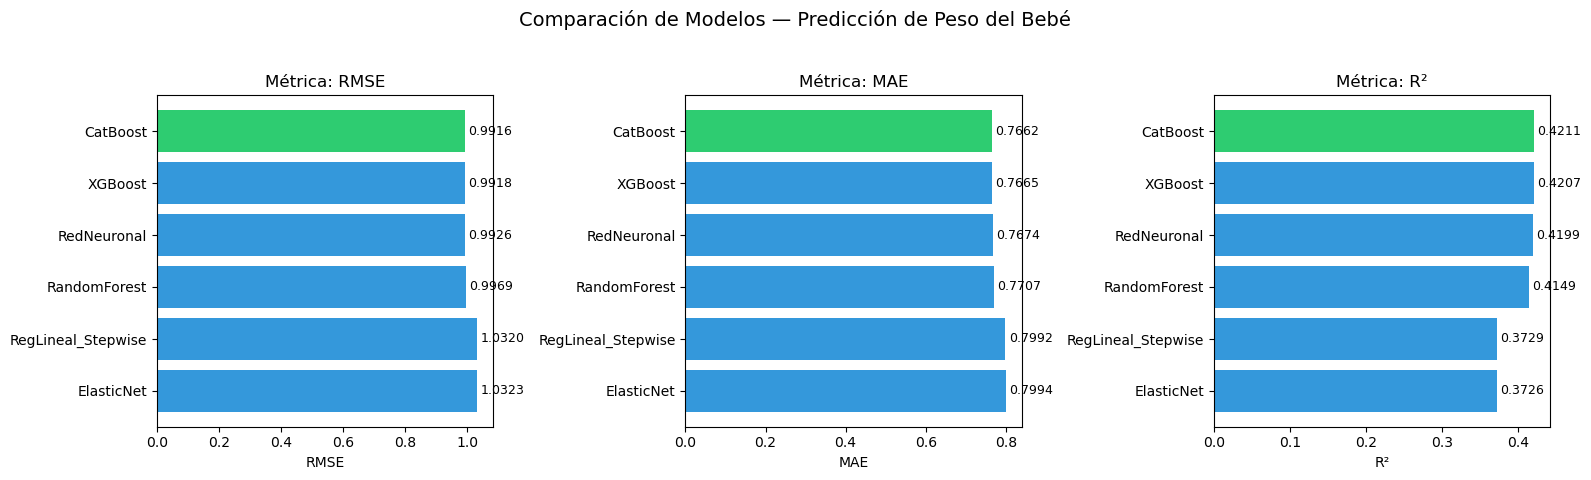

,Ranking,Modelo,RMSE,MAE,R²
0,1,CatBoost,0.9916,0.7662,0.4211
1,2,XGBoost,0.9918,0.7665,0.4207
2,3,RedNeuronal,0.9926,0.7674,0.4199
3,4,RandomForest,0.9969,0.7707,0.4149
4,5,RegLineal_Stepwise,1.0320,0.7992,0.3729
5,6,ElasticNet,1.0323,0.7994,0.3726


In [54]:

# 1. Aseguramos que el modelo base esté en el formato correcto
if 'metricas_sw' in locals():
    results['RegLineal_Stepwise'] = {
        'RMSE': float(metricas_sw['RMSE Test']),
        'MAE':  float(metricas_sw['MAE Test']),
        'R2':   float(metricas_sw['R² Test']),
        'preds': y_test_pred_sw.values
    }

# 2. Construir filas manejando formatos híbridos (Número vs Diccionario)
comparison_rows = []
for nombre, m in results.items():
    if isinstance(m, dict):
        comparison_rows.append({
            'Modelo': nombre, 
            'RMSE': m.get('RMSE'),
            'MAE': m.get('MAE'), 
            'R²': m.get('R2')
        })
    elif isinstance(m, (float, np.float64, int)):
        # Si es un modelo viejo que solo guardó el RMSE
        comparison_rows.append({
            'Modelo': nombre, 
            'RMSE': m,
            'MAE': np.nan, 
            'R²': np.nan
        })

# 3. Crear y ordenar DataFrame
df_results = (pd.DataFrame(comparison_rows)
              .sort_values('RMSE')
              .reset_index(drop=True))
df_results.insert(0, 'Ranking', df_results.index + 1)

# 4. Imprimir Tabla de texto
print('=' * 65)
print('   TABLA COMPARATIVA FINAL DE MODELOS (Test Set)')
print('=' * 65)
print(df_results[['Ranking', 'Modelo', 'RMSE', 'MAE', 'R²']].to_string(index=False))
print('=' * 65)

# 5. Gráfico de barras mejorado
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparación de Modelos — Predicción de Peso del Bebé', fontsize=14)

# Colores: Verde para el mejor, azul para el resto
colores = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(df_results))]

for ax, metrica in zip(axes, ['RMSE', 'MAE', 'R²']):
    # Filtrar nulos para el gráfico
    temp_df = df_results.dropna(subset=[metrica])
    vals = temp_df[metrica]
    bars = ax.barh(temp_df['Modelo'], vals, color=colores[:len(temp_df)])
    
    ax.set_xlabel(metrica)
    ax.set_title(f'Métrica: {metrica}')
    ax.invert_yaxis()
    
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 6. Mostrar tabla con gradiente (ideal para Jupyter)
df_results.style\
    .background_gradient(subset=['RMSE', 'MAE'], cmap='RdYlGn_r')\
    .background_gradient(subset=['R²'], cmap='RdYlGn')\
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R²': '{:.4f}'})

In [55]:
mejor_modelo = df_results.iloc[0]['Modelo']

### Análisis de Residuos del Mejor Modelo

Los residuos deben estar centrados en 0 y distribuirse de forma aproximadamente normal para confirmar que el modelo no tiene sesgo sistemático. Un patrón en el gráfico "Residuos vs Predicciones" indicaría heterocedasticidad (varianza no constante del error).

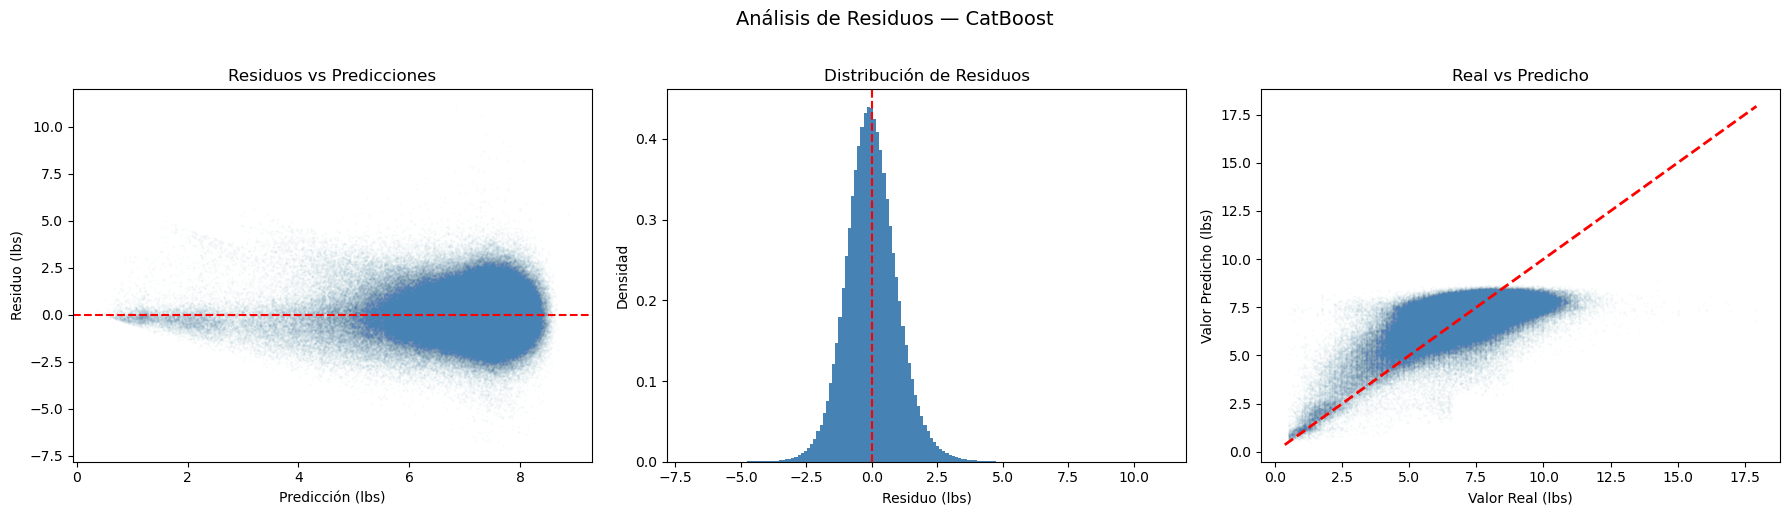

Estadísticas de residuos — Modelo: CatBoost
  Media:        -0.0029 lbs
  Desv. Est.:   0.9916 lbs
  |Res| > 1 lb: 28.5% de las predicciones


In [56]:
# === GRÁFICO DE RESIDUOS — MEJOR MODELO ===

mejor_preds = np.array(results[mejor_modelo]['preds'], dtype=np.float32)
residuos    = y_test_np - mejor_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Análisis de Residuos — {mejor_modelo}', fontsize=14, y=1.02)

# 1. Residuos vs Predicciones
axes[0].scatter(mejor_preds, residuos, alpha=0.02, s=1, color='steelblue', rasterized=True)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicción (lbs)')
axes[0].set_ylabel('Residuo (lbs)')
axes[0].set_title('Residuos vs Predicciones')

# 2. Distribución de residuos
axes[1].hist(residuos, bins=150, color='steelblue', edgecolor='none', density=True)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residuo (lbs)')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución de Residuos')

# 3. Real vs Predicho
axes[2].scatter(y_test_np, mejor_preds, alpha=0.02, s=1, color='steelblue', rasterized=True)
lim_min = float(min(y_test_np.min(), mejor_preds.min()))
lim_max = float(max(y_test_np.max(), mejor_preds.max()))
axes[2].plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=2)
axes[2].set_xlabel('Valor Real (lbs)')
axes[2].set_ylabel('Valor Predicho (lbs)')
axes[2].set_title('Real vs Predicho')

plt.tight_layout()
plt.show()

print(f'Estadísticas de residuos — Modelo: {mejor_modelo}')
print(f'  Media:        {residuos.mean():.4f} lbs')
print(f'  Desv. Est.:   {residuos.std():.4f} lbs')
print(f'  |Res| > 1 lb: {(np.abs(residuos) > 1).mean()*100:.1f}% de las predicciones')

### Explicabilidad del Modelo (SHAP)

**SHAP** (SHapley Additive exPlanations) cuantifica la contribución de cada variable a cada predicción individual, basándose en la teoría de juegos de Shapley. 

**Nota de eficiencia**: el dataset tiene ~4M filas; se usa una **muestra de 1,000 registros** del test set para calcular los SHAP values.

Calculando SHAP values para: CatBoost
Muestra: 1,000 registros del test set

SHAP values calculados: (1000, 51)


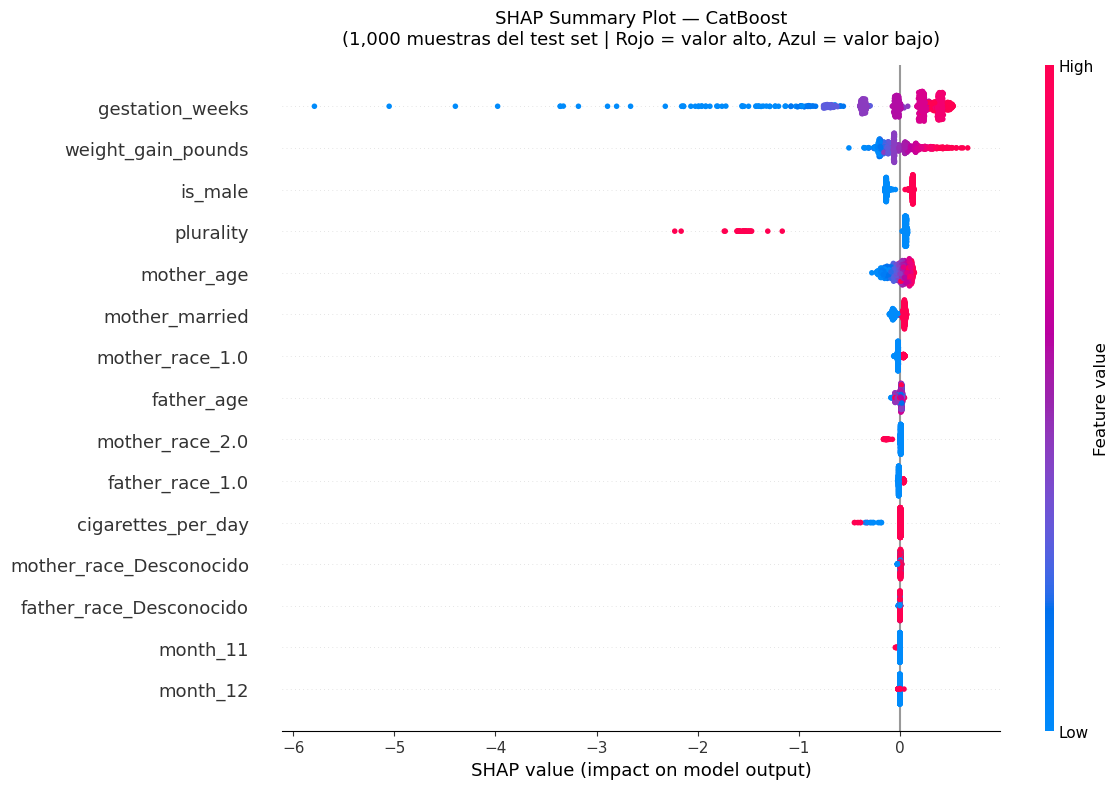

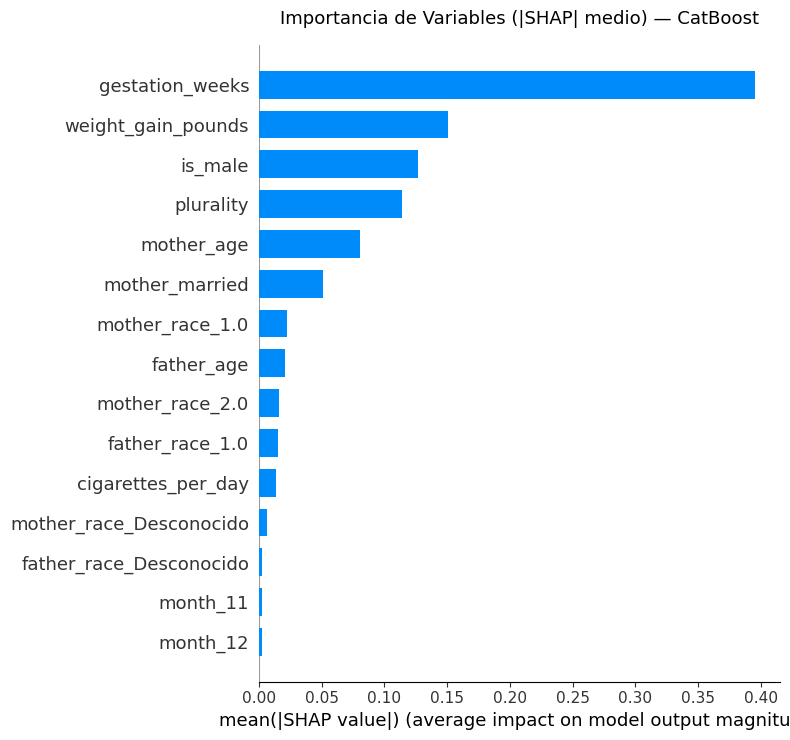


Top 10 variables más influyentes en el peso del bebé:
              Variable  SHAP medio (lbs)
1      gestation_weeks          0.395387
2   weight_gain_pounds          0.150555
3              is_male          0.126932
4            plurality          0.113899
5           mother_age          0.080233
6       mother_married          0.051431
7      mother_race_1.0          0.022238
8           father_age          0.020608
9      mother_race_2.0          0.016398
10     father_race_1.0          0.015149

Interpretación: un SHAP medio de X indica que esta variable cambia
la predicción en ±X libras respecto a la predicción base del modelo.


In [57]:
# === ANÁLISIS DE EXPLICABILIDAD SHAP ===

print(f'Calculando SHAP values para: {mejor_modelo}')
print('Muestra: 1,000 registros del test set\n')

# Muestra representativa de 1,000 registros del test set
np.random.seed(SEED)
shap_idx  = np.random.choice(X_test_proc.shape[0], size=1000, replace=False)
X_shap    = X_test_proc[shap_idx]

# DataFrame con nombres de features para los plots
X_shap_df = pd.DataFrame(X_shap, columns=feature_names[:X_shap.shape[1]])

# Seleccionar el explainer según el mejor modelo
if mejor_modelo == 'XGBoost':
    explainer = shap.TreeExplainer(xgb_model)
    shap_vals = explainer.shap_values(xgb.DMatrix(X_shap))
elif mejor_modelo == 'CatBoost':
    explainer = shap.TreeExplainer(cat_final)
    shap_vals = explainer.shap_values(X_shap)
elif mejor_modelo == 'RandomForest':
    explainer = shap.TreeExplainer(rf_final)
    shap_vals = explainer.shap_values(X_shap)
elif mejor_modelo == 'ElasticNet':
    explainer = shap.LinearExplainer(en_final, X_train_proc[:1000])
    shap_vals = explainer.shap_values(X_shap)
elif mejor_modelo == 'RedNeuronal':
    model_pro.eval()
    background = torch.FloatTensor(X_train_proc[:200]).to(device)
    explainer  = shap.DeepExplainer(model_pro, background)
    shap_vals  = explainer.shap_values(torch.FloatTensor(X_shap).to(device))
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[0]
else:  # RegLineal_Stepwise: usar LinearExplainer con ElasticNet como proxy
    print('Usando LinearExplainer con ElasticNet como proxy para OLS.')
    explainer = shap.LinearExplainer(en_final, X_train_proc[:1000])
    shap_vals = explainer.shap_values(X_shap)

shap_vals = np.array(shap_vals)
print(f'SHAP values calculados: {shap_vals.shape}')

# 1. SHAP Summary Plot (Beeswarm)
# Eje X = impacto en la predicción; Color: rojo = valor alto, azul = valor bajo
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_vals, X_shap_df, show=False, max_display=15, plot_size=None)
plt.title(
    f'SHAP Summary Plot — {mejor_modelo}\n'
    '(1,000 muestras del test set | Rojo = valor alto, Azul = valor bajo)',
    fontsize=13, pad=15
)
plt.tight_layout()
plt.show()

# 2. SHAP Bar Plot (Importancia global = |SHAP| medio por variable)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_shap_df, plot_type='bar', show=False, max_display=15)
plt.title(
    f'Importancia de Variables (|SHAP| medio) — {mejor_modelo}',
    fontsize=13, pad=15
)
plt.tight_layout()
plt.show()

# Top 10 variables más influyentes
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
shap_importance = (
    pd.DataFrame({'Variable': feature_names[:len(mean_abs_shap)],
                  'SHAP medio (lbs)': mean_abs_shap})
    .sort_values('SHAP medio (lbs)', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
shap_importance.index += 1

print('\nTop 10 variables más influyentes en el peso del bebé:')
print(shap_importance.to_string())
print('\nInterpretación: un SHAP medio de X indica que esta variable cambia')
print('la predicción en ±X libras respecto a la predicción base del modelo.')

### Una medición del desempeño a la hora de detectar bajo peso en bebés

Aunque el objetivo principal de este estudio es la predicción del peso exacto mediante modelos de regresión, la utilidad clínica de estos algoritmos radica en su capacidad para identificar neonatos en riesgo. Según Stanford Medicine Children's Health, un bebé tiene "Bajo Peso al Nacer" (LBW) si su peso es inferior a 2,500 gramos, lo que equivale a 5.511557 libras.

**Transformación de Regresión a Clasificación Binaria**

Para evaluar esta capacidad, convertimos las predicciones continuas del modelo en etiquetas categóricas mediante una función de umbral ($threshold$):$$C = \begin{cases} 1 & \text{si } \hat{y} < 5.511557 \text{ lbs (Bajo Peso)} \\ 0 & \text{si } \hat{y} \ge 5.511557 \text{ lbs (Peso Normal)} \end{cases}$$

**Métricas de Evaluación en Salud Pública**

En el análisis de salud, el costo de un error varía drásticamente según su tipo. Por ello, se implementan las siguientes métricas de clasificación:
- Recall (Sensibilidad): Es la métrica más crítica en este contexto. Representa la proporción de bebés con bajo peso real que el modelo logró capturar correctamente. Un Recall bajo implica "Falsos Negativos", lo cual se traduce en bebés en situación de riesgo que no recibirían intervención médica preventiva.
- Precisión (Fiabilidad): Mide la exactitud de las alertas de bajo peso. Una baja precisión genera "Falsos Positivos", lo que puede causar angustia innecesaria a los padres y una saturación ineficiente de las unidades de cuidados intensivos neonatales.
- F1-Score: Es el promedio armónico entre la Precisión y el Recall. Dado que el conjunto de datos de la CDC suele presentar un desbalance de clases (pocos casos de bajo peso en comparación con peso normal), el F1-Score es un indicador mucho más honesto que el Accuracy global.

**Matriz de Confusión y Validación Clínica**

Para visualizar el rendimiento, se utiliza la Matriz de Confusión, permitiendo cuantificar los casos específicos de éxito y error.

ANÁLISIS DE DIAGNÓSTICO CLÍNICO: DETECCIÓN DE BAJO PESO AL NACER
Umbral: < 5.5116 lbs | Muestra de prueba: 850,141 registros

Evaluando: XGBoost...
Evaluando: RedNeuronal...
Evaluando: ElasticNet...
Evaluando: RandomForest...
Evaluando: CatBoost...
Evaluando: RegLineal_Stepwise...


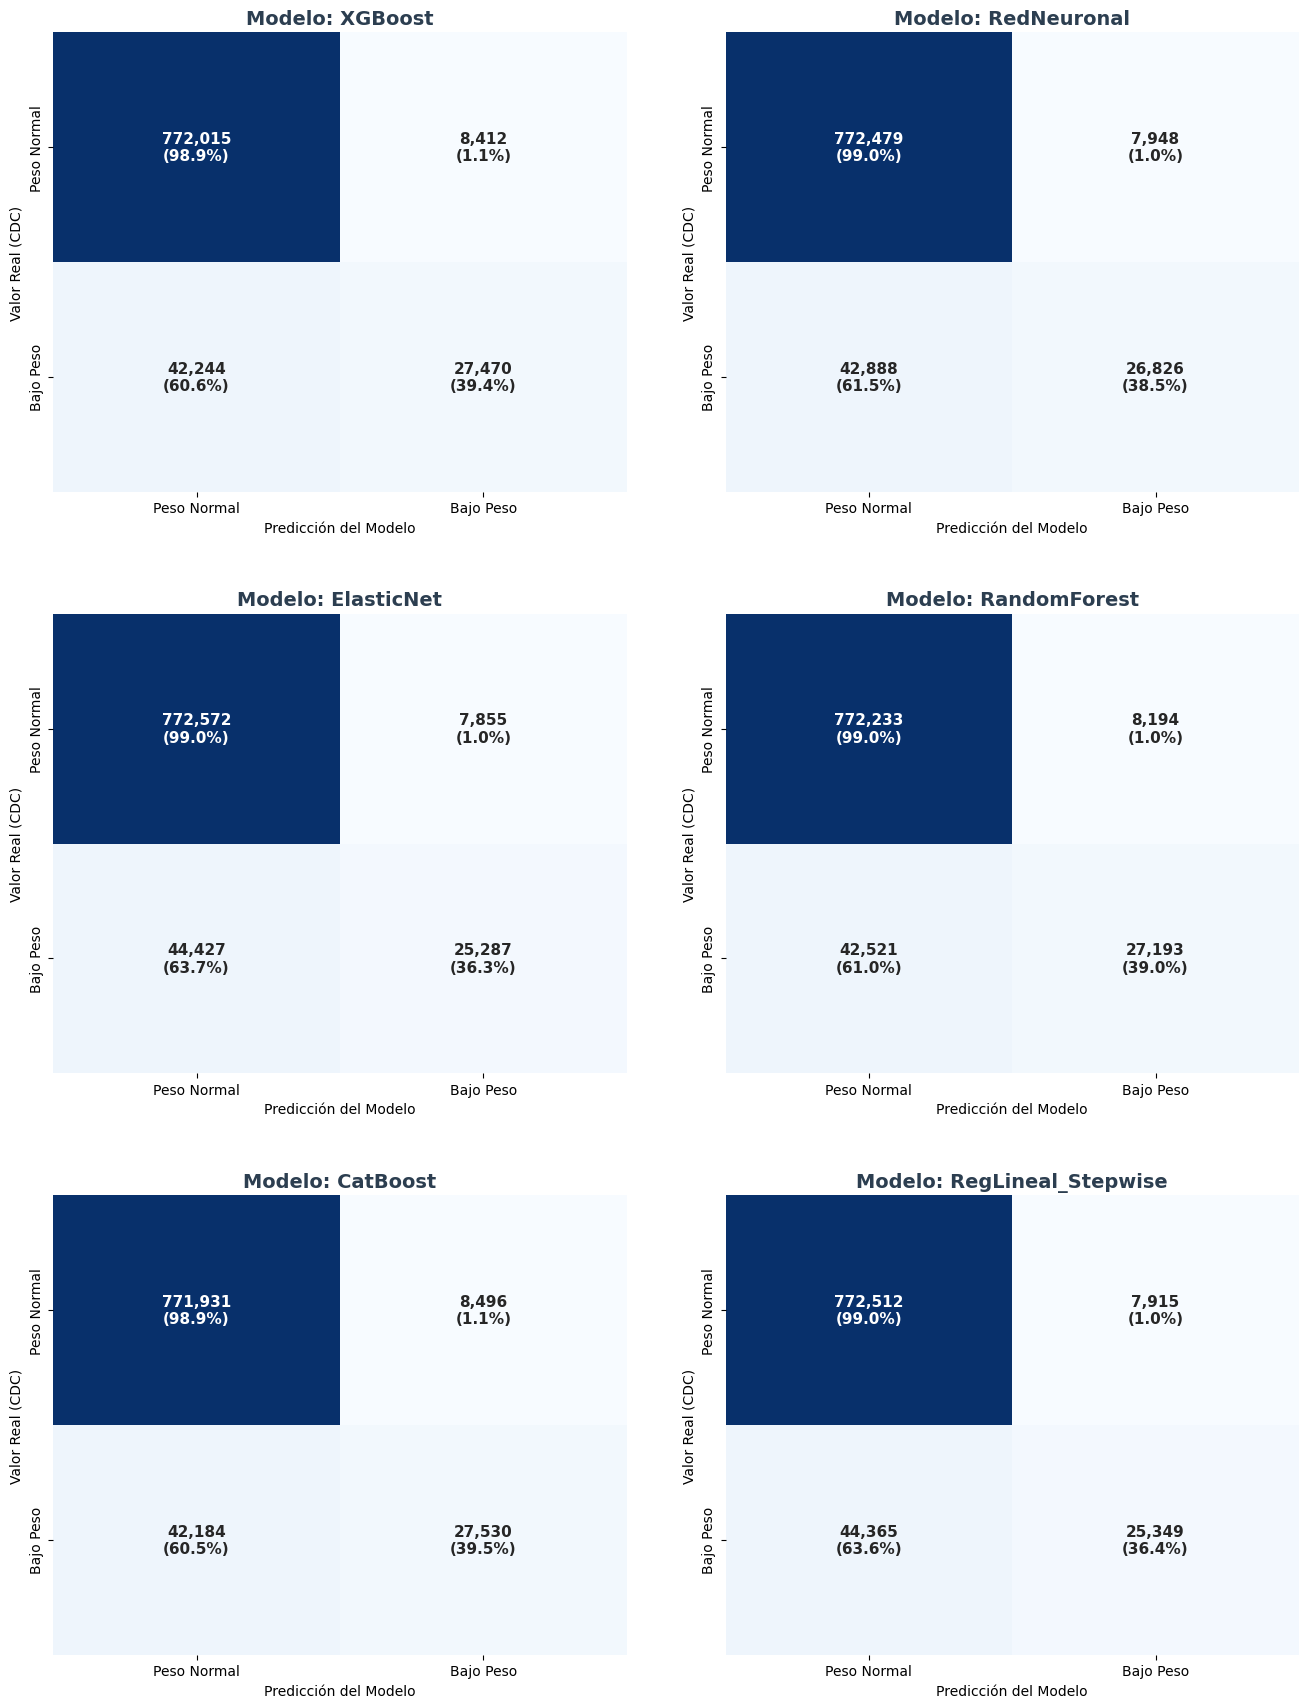


RESUMEN COMPARATIVO DE CAPACIDAD DIAGNÓSTICA (Ordenado por Recall)


,Modelo,Recall (Sensibilidad),Precisión,F1-Score,Accuracy
4,CatBoost,0.3949,0.7642,0.5207,0.9404
0,XGBoost,0.3940,0.7656,0.5203,0.9404
3,RandomForest,0.3901,0.7684,0.5175,0.9403
1,RedNeuronal,0.3848,0.7714,0.5135,0.9402
5,RegLineal_Stepwise,0.3636,0.7621,0.4923,0.9385
2,ElasticNet,0.3627,0.7630,0.4917,0.9385


In [62]:
# ==============================================================================
# 1. CONFIGURACIÓN INICIAL Y UMBRAL MÉDICO (Stanford Medicine)
# ==============================================================================
# Bajo peso al nacer: < 2,500 gramos = 5.511557 libras
THRESHOLD_LBW = 5.511557

# Binarizamos los valores reales (y_test_np debe estar en memoria)
# 1: Bajo Peso (Riesgo), 0: Peso Normal
y_actual_bin = (y_test_np < THRESHOLD_LBW).astype(int)

# Lista para recolectar métricas para la tabla comparativa
res_clasificacion = []

# ==============================================================================
# 2. CONFIGURACIÓN DE LA CUADRÍCULA DE IMÁGENES (3 Filas x 2 Columnas)
# ==============================================================================
n_modelos = len(results)
rows, cols = 3, 2
fig, axes = plt.subplots(rows, cols, figsize=(14, 18))
axes = axes.flatten()  # Aplanamos la matriz para iterar fácilmente

print(f"{'='*70}")
print(f"ANÁLISIS DE DIAGNÓSTICO CLÍNICO: DETECCIÓN DE BAJO PESO AL NACER")
print(f"Umbral: < {THRESHOLD_LBW:.4f} lbs | Muestra de prueba: {len(y_actual_bin):,} registros")
print(f"{'='*70}\n")

# ==============================================================================
# 3. BUCLE DE PROCESAMIENTO POR MODELO
# ==============================================================================
for i, (nombre_modelo, data) in enumerate(results.items()):
    if i >= len(axes): break # Seguridad por si hay más de 6 modelos
    
    # Extraer y binarizar predicciones del modelo
    y_pred_reg = data['preds']
    y_pred_bin = (y_pred_reg < THRESHOLD_LBW).astype(int)
    
    # Cálculo de métricas de clasificación
    metrics = {
        'Modelo': nombre_modelo,
        'Recall (Sensibilidad)': recall_score(y_actual_bin, y_pred_bin),
        'Precisión': precision_score(y_actual_bin, y_pred_bin),
        'F1-Score': f1_score(y_actual_bin, y_pred_bin),
        'Accuracy': (y_actual_bin == y_pred_bin).mean()
    }
    res_clasificacion.append(metrics)
    
    # Impresión de reporte detallado en consola
    print(f"Evaluando: {nombre_modelo}...")
    
    # Cálculo de la Matriz de Confusión
    cm = confusion_matrix(y_actual_bin, y_pred_bin)
    
    # Normalización para obtener porcentajes por fila (Efectividad de detección)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Etiquetas personalizadas: Cantidad absoluta + Porcentaje relativo
    labels = np.array([
        [f"{cm[0,0]:,}\n({cm_norm[0,0]:.1%})", f"{cm[0,1]:,}\n({cm_norm[0,1]:.1%})"],
        [f"{cm[1,0]:,}\n({cm_norm[1,0]:.1%})", f"{cm[1,1]:,}\n({cm_norm[1,1]:.1%})"]
    ])
    
    # Visualización del Heatmap
    sns.heatmap(cm, annot=labels, fmt="", cmap='Blues', ax=axes[i], 
                cbar=False, annot_kws={"size": 11, "fontweight": 'bold'})
    
    # Estética de los subplots
    axes[i].set_title(f"Modelo: {nombre_modelo}", fontsize=14, fontweight='bold', color='#2c3e50')
    axes[i].set_xlabel("Predicción del Modelo", fontsize=10)
    axes[i].set_ylabel("Valor Real (CDC)", fontsize=10)
    axes[i].set_xticklabels(['Peso Normal', 'Bajo Peso'])
    axes[i].set_yticklabels(['Peso Normal', 'Bajo Peso'])

# Eliminar ejes sobrantes si tienes menos de 6 modelos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=4.0)
plt.show()

# ==============================================================================
# 4. TABLA COMPARATIVA FINAL
# ==============================================================================
df_comparativo = pd.DataFrame(res_clasificacion).sort_values(by='Recall (Sensibilidad)', ascending=False)

print("\n" + "="*70)
print("RESUMEN COMPARATIVO DE CAPACIDAD DIAGNÓSTICA (Ordenado por Recall)")
print("="*70)

# Estilizamos la tabla para resaltar los mejores modelos en detección de riesgo
display(df_comparativo.style.highlight_max(
    subset=['Recall (Sensibilidad)', 'F1-Score'], 
    color='#d4edda' # Verde claro para los ganadores
).format({
    'Recall (Sensibilidad)': '{:.4f}',
    'Precisión': '{:.4f}',
    'F1-Score': '{:.4f}',
    'Accuracy': '{:.4f}'
}))